# 05 — Hedef Tasarımı ve Hane × Snapshot Feature Engineering

## Bu notebook neyi çözüyor?

İlk dört notebook veri kaynaklarını temizledi ve işlem, ürün, müşteri, demografi,
kampanya ve kupon yapılarını ayrı ayrı inceledi. Bu notebook bu kaynakları
**geleceği görmeden**, modellemeye uygun tek bir panel tabloda birleştirir.

Yanıtlamak istediğimiz soru:

> Bir snapshot gününe kadar gözlenen davranışına göre bir hane, izleyen tahmin
> döneminde hiç geçerli alışveriş sepeti oluşturmayacak mı?

Bu tanım sözleşmeli bir hizmetteki kesin müşteri kaybını değil, perakende bağlamında
**ileri dönem alışveriş pasifliğini** ölçer.

### Nihai analiz birimi

Her satır bir `household_key × snapshot_day` gözlemidir. Aynı hane farklı
snapshot'larda yeniden puanlanabilir. Böylece:

- Tek cutoff'a bağımlılık azalır.
- Daha fazla pozitif örnek elde edilir.
- Train, validation ve test dönemleri kronolojik olarak ayrılabilir.
- Modelin farklı zamanlarda kararlı çalışıp çalışmadığı ölçülebilir.

### Temel sızıntı kuralı

Bir snapshot için hedef dönemindeki hiçbir işlem, ürün, sepet, kampanya sonucu veya
kupon kullanımı feature üretiminde kullanılamaz. Demografi zaman damgası içermediği
için davranışsal ana modele zorunlu olarak eklenmez; ayrı bir deney katmanı olarak
saklanır.

## Notebook akışı

1. Temiz Parquet tablolarını `data/interim` klasöründen yükleme
2. İlişkisel bütünlük ve iş kuralı kontrolleri
3. Müşteri ödemesi, indirim ve özel işlem satırı tanımları
4. Hedef penceresi duyarlılık analizi
5. Çoklu snapshot hedef panelinin oluşturulması
6. RFM, sepet, ritim, trend, ürün, kampanya ve demografi feature'ları
7. Feature tablolarının güvenli biçimde birleştirilmesi
8. Eğitim verisi üzerinde kalite, korelasyon ve sızıntı kontrolleri
9. Çekirdek ve genişletilmiş feature setlerinin kaydedilmesi

> Eksik değer doldurma, kategorik encoding, ölçekleme ve model tabanlı feature
> seçimi bu notebook'ta yapılmaz. Bunlar yalnızca eğitim fold'larında uygulanmak
> üzere `06_modeling.ipynb` içinde pipeline'a alınmalıdır.

## 1. Kütüphaneler ve proje yolları

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

COLORS = {
    "blue": "#3B6EA8",
    "light_blue": "#8CB9E8",
    "orange": "#F28E2B",
    "red": "#D9534F",
    "green": "#2A9D8F",
    "gray": "#7A7A7A",
    "light_gray": "#E9ECEF",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


def first_existing_path(candidates):
    '''İlk bulunan yolu döndürür; hiçbiri yoksa açıklayıcı hata verir.'''
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Proje veri klasörü bulunamadı. Kontrol edilen yollar: "
        + ", ".join(map(str, candidates))
    )


INTERIM_PATH = first_existing_path([
    Path("data") / "interim",
    Path("../data") / "interim",
])
DATA_ROOT = INTERIM_PATH.parent
PROCESSED_PATH = DATA_ROOT / "processed"
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print(f"Temiz kaynak tablolar : {INTERIM_PATH.resolve()}")
print(f"Modelleme çıktıları   : {PROCESSED_PATH.resolve()}")

Temiz kaynak tablolar : C:\Users\ed024981\Desktop\Miuul_project\data\interim
Modelleme çıktıları   : C:\Users\ed024981\Desktop\Miuul_project\data\processed


### Neden `interim` ve `processed` ayrılıyor?

- `data/interim`: `01_data_preparation.ipynb` tarafından temizlenmiş, ancak henüz
  model feature'ına dönüştürülmemiş kaynak tablolar.
- `data/processed`: Bu notebook tarafından üretilen hane × snapshot model tablosu.

Bu ayrım eski veya farklı hazırlanmış Parquet dosyalarının yanlışlıkla modele
girmesini önler.

## 2. Temiz tabloların yüklenmesi

In [2]:
def load_prepared_table(table_name):
    '''01 notebook'unun oluşturduğu temiz Parquet tablosunu yükler.'''
    path = INTERIM_PATH / f"{table_name}.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} bulunamadı. Önce 01_data_preparation.ipynb çalıştırılmalıdır."
        )
    dataframe = pd.read_parquet(path)
    print(f"{table_name:20} -> {dataframe.shape}")
    return dataframe


transaction_data = load_prepared_table("transaction_data")
product = load_prepared_table("product")
hh_demographic = load_prepared_table("hh_demographic")
campaign_desc = load_prepared_table("campaign_desc")
campaign_table = load_prepared_table("campaign_table")
coupon = load_prepared_table("coupon")
coupon_redempt = load_prepared_table("coupon_redempt")

transaction_data     -> (2595732, 12)
product              -> (92353, 7)
hh_demographic       -> (801, 8)
campaign_desc        -> (30, 4)
campaign_table       -> (7208, 3)
coupon               -> (119384, 3)
coupon_redempt       -> (2318, 4)


### Ürün metin alanlarında gizli boşluk kontrolü

`product` tablosunda eksik değer yalnızca `NaN` biçiminde bulunmayabilir; boş
string (`""`) veya yalnızca boşluk içeren hücreler de ayrı, görünmez bir kategori
oluşturabilir. Özellikle `curr_size_of_product` alanının User Guide'a göre bütün
ürünlerde bulunması beklenmez ve bu sütun model feature'ı olarak kullanılmaz.

Aşağıdaki kontrol önce ham `NaN` ve gizli boşluk sayılarını raporlar. Modelde
kullanılan `department`, `commodity_desc`, `sub_commodity_desc` ve `brand`
alanlarında bütün bu değerler tek bir `MISSING` kategorisinde standartlaştırılır.
Bu işlem `TOP_DEPARTMENTS` ve kategori paylarında görünmez `""` sınıfı oluşmasını
önler.

In [3]:
PRODUCT_MODEL_TEXT_COLUMNS = [
    "department", "commodity_desc", "sub_commodity_desc", "brand",
]
PRODUCT_TEXT_AUDIT_COLUMNS = (
    PRODUCT_MODEL_TEXT_COLUMNS + ["curr_size_of_product"]
)


def hidden_blank_mask(series):
    text = series.astype("string")
    return text.str.strip().eq("").fillna(False)


def normalize_missing_text(series):
    text = series.astype("string").str.strip()
    return text.replace("", pd.NA).fillna("MISSING")


product_text_quality = pd.DataFrame({
    "raw_nan_count": [
        int(product[column].isna().sum())
        for column in PRODUCT_TEXT_AUDIT_COLUMNS
    ],
    "blank_or_whitespace_count": [
        int(hidden_blank_mask(product[column]).sum())
        for column in PRODUCT_TEXT_AUDIT_COLUMNS
    ],
    "used_in_model": [
        column in PRODUCT_MODEL_TEXT_COLUMNS
        for column in PRODUCT_TEXT_AUDIT_COLUMNS
    ],
}, index=PRODUCT_TEXT_AUDIT_COLUMNS)

for column in PRODUCT_MODEL_TEXT_COLUMNS:
    product[column] = normalize_missing_text(product[column])

product_text_quality["missing_category_count_after"] = [
    int(product[column].astype("string").eq("MISSING").sum())
    if column in PRODUCT_MODEL_TEXT_COLUMNS else pd.NA
    for column in PRODUCT_TEXT_AUDIT_COLUMNS
]

assert product[PRODUCT_MODEL_TEXT_COLUMNS].notna().all().all()
assert not any(
    hidden_blank_mask(product[column]).any()
    for column in PRODUCT_MODEL_TEXT_COLUMNS
)

display(product_text_quality)

,raw_nan_count,blank_or_whitespace_count,used_in_model,missing_category_count_after
department,15,0,True,15
commodity_desc,15,0,True,15
sub_commodity_desc,15,0,True,15
brand,0,0,True,0
curr_size_of_product,30607,0,False,<NA>


## 3. Şema ve ilişkisel bütünlük kontrolleri

Tabloları birleştirmeden önce her ilişkinin beklenen yönü doğrulanır:

| İlişki | Beklenen yapı |
|---|---|
| Transaction → Product | many-to-one (`product_id`) |
| Campaign assignment → Campaign description | many-to-one (`campaign`) |
| Coupon redemption → Campaign | many-to-one (`campaign`) |
| Demography → Household | one-to-one (`household_key`) |

`coupon` tablosu kupon–ürün ilişkisidir. Bir kupon birden fazla üründe geçerli
olabildiği için bu tablo işlem verisine doğrudan eklenmez. Aksi halde many-to-many
birleşme satır ve tutarları yapay olarak çoğaltabilir.

In [4]:
required_columns = {
    "transaction_data": {
        "household_key", "basket_id", "day", "week_no", "product_id",
        "quantity", "sales_value", "store_id", "retail_disc", "coupon_disc",
        "coupon_match_disc", "trans_time",
    },
    "product": {
        "product_id", "department", "commodity_desc", "sub_commodity_desc",
        "manufacturer", "brand", "curr_size_of_product",
    },
    "hh_demographic": {"household_key"},
    "campaign_desc": {"campaign", "description", "start_day", "end_day"},
    "campaign_table": {"household_key", "campaign", "description"},
    "coupon": {"coupon_upc", "product_id", "campaign"},
    "coupon_redempt": {"household_key", "day", "coupon_upc", "campaign"},
}

loaded_tables = {
    "transaction_data": transaction_data,
    "product": product,
    "hh_demographic": hh_demographic,
    "campaign_desc": campaign_desc,
    "campaign_table": campaign_table,
    "coupon": coupon,
    "coupon_redempt": coupon_redempt,
}

for table_name, expected_columns in required_columns.items():
    missing_columns = expected_columns - set(loaded_tables[table_name].columns)
    assert not missing_columns, (
        f"{table_name} tablosunda eksik sütunlar: {sorted(missing_columns)}"
    )

assert product["product_id"].is_unique, "product.product_id benzersiz olmalıdır."
assert hh_demographic["household_key"].is_unique, (
    "hh_demographic.household_key benzersiz olmalıdır."
)
assert campaign_desc["campaign"].is_unique, (
    "campaign_desc.campaign benzersiz olmalıdır."
)
assert not campaign_table.duplicated(["household_key", "campaign"]).any(), (
    "Aynı hane–kampanya ataması birden fazla kez bulunuyor."
)

campaign_description_check = (
    campaign_table[["campaign", "description"]]
    .drop_duplicates()
    .merge(
        campaign_desc[["campaign", "description"]],
        on="campaign",
        how="outer",
        suffixes=("_table", "_desc"),
        indicator=True,
        validate="one_to_one",
    )
)
campaign_description_check["matches"] = (
    campaign_description_check["_merge"].eq("both")
    & campaign_description_check["description_table"].eq(
        campaign_description_check["description_desc"]
    )
)

coupon_pairs = coupon[["campaign", "coupon_upc"]].drop_duplicates()
redemption_coupon_check = (
    coupon_redempt[["campaign", "coupon_upc"]]
    .drop_duplicates()
    .merge(
        coupon_pairs,
        on=["campaign", "coupon_upc"],
        how="left",
        indicator=True,
        validate="many_to_one",
    )
)

campaign_household_pairs = pd.MultiIndex.from_frame(
    campaign_table[["household_key", "campaign"]].drop_duplicates()
)
redemption_household_pairs = pd.MultiIndex.from_frame(
    coupon_redempt[["household_key", "campaign"]]
)

relationship_checks = pd.Series({
    "campaign_descriptions_match": bool(campaign_description_check["matches"].all()),
    "all_redemption_coupons_exist": bool(
        redemption_coupon_check["_merge"].eq("both").all()
    ),
    "all_redeemers_received_campaign": bool(
        redemption_household_pairs.isin(campaign_household_pairs).all()
    ),
    "all_transaction_products_exist": bool(
        transaction_data["product_id"].isin(product["product_id"]).all()
    ),
})

display(relationship_checks.to_frame("passed"))
assert relationship_checks.all(), "İlişkisel bütünlük kontrollerinden en az biri başarısız."

,passed
campaign_descriptions_match,True
all_redemption_coupons_exist,True
all_redeemers_received_campaign,True
all_transaction_products_exist,True


## 4. Parasal değişkenler ve işlem satırı türleri

User Guide'a göre `sales_value`, müşterinin ödediği tutar değil, üretici kuponu
geri ödemesi dahil perakendecinin elde ettiği tutardır. Kupon indirimleri veri
setinde negatif işaretle tutulur.

Bu nedenle:

\[
Customer\ Paid = Sales\ Value + Coupon\ Discount
\]

Müşteri davranışıyla ilgili RFM, sepet ve trend feature'larında
`customer_paid_value`; kategori karmasında ise kuponun ayrı muhasebe satırlarına
dağılma probleminden kaçınmak için ürün satırındaki `retailer_revenue` kullanılır.

### Kupon muhasebe satırları

Bazı kuponlar `quantity=0`, `sales_value=0`, `coupon_disc<0` olan ayrı satırlarda
tutulur. Bu satırlar:

- Hane ve sepet toplamında müşteri ödemesini hesaplarken korunur.
- Ürün çeşitliliği ve kategori tercihi hesaplarken dışarıda bırakılır.
- Tek başına gerçek alışveriş sepeti sayılmaz.

In [5]:
transactions = transaction_data.copy()

transactions["retailer_revenue"] = transactions["sales_value"]
transactions["customer_paid_value"] = (
    transactions["sales_value"] + transactions["coupon_disc"]
)
transactions["retail_discount_amount"] = -transactions["retail_disc"].clip(upper=0)
transactions["coupon_discount_amount"] = -transactions["coupon_disc"].clip(upper=0)
transactions["coupon_match_discount_amount"] = -(
    transactions["coupon_match_disc"].clip(upper=0)
)
transactions["total_discount_amount"] = (
    transactions["retail_discount_amount"]
    + transactions["coupon_discount_amount"]
    + transactions["coupon_match_discount_amount"]
)
transactions["has_any_discount"] = transactions["total_discount_amount"].gt(0)
transactions["has_coupon_discount"] = transactions["coupon_discount_amount"].gt(0)

transactions["is_coupon_accounting_line"] = (
    transactions["quantity"].eq(0)
    & transactions["sales_value"].eq(0)
    & transactions["coupon_disc"].lt(0)
)
transactions["is_purchase_line"] = (
    ~transactions["is_coupon_accounting_line"]
    & (transactions["quantity"].gt(0) | transactions["sales_value"].gt(0))
)
transactions["purchase_line_has_any_discount"] = np.where(
    transactions["is_purchase_line"],
    transactions["has_any_discount"].astype(float),
    np.nan,
)
transactions["purchase_line_has_coupon_discount"] = np.where(
    transactions["is_purchase_line"],
    transactions["has_coupon_discount"].astype(float),
    np.nan,
)

trans_time = pd.to_numeric(transactions["trans_time"], errors="coerce")
transaction_hour = (trans_time // 100).astype("float")
transaction_minute = (trans_time % 100).astype("float")
valid_clock = transaction_hour.between(0, 23) & transaction_minute.between(0, 59)
transactions["transaction_hour"] = transaction_hour.where(valid_clock)

transaction_rule_summary = pd.Series({
    "transaction_lines": len(transactions),
    "coupon_accounting_lines": int(transactions["is_coupon_accounting_line"].sum()),
    "purchase_lines": int(transactions["is_purchase_line"].sum()),
    "negative_customer_paid_lines": int(
        transactions["customer_paid_value"].lt(0).sum()
    ),
    "invalid_transaction_times": int(transactions["transaction_hour"].isna().sum()),
})
transaction_rule_summary.to_frame("count")

,count
transaction_lines,2595732
coupon_accounting_lines,4955
purchase_lines,2581333
negative_customer_paid_lines,5819
invalid_transaction_times,0


## 5. Geçerli alışveriş sepetlerinin oluşturulması

Hedef “gelecekte hiç alışveriş sepeti yok” biçiminde tanımlandığı için yalnızca
kupon muhasebe satırından oluşan olaylar gerçek ziyaret gibi sayılmamalıdır.
Bir sepet, en az bir `is_purchase_line=True` satırı içeriyorsa geçerli alışveriş
sepeti kabul edilir.

Müşteri ödeme tutarı sepet içindeki bütün satırlar üzerinden toplanır; böylece
ayrı kupon satırları ürün alışverişinin toplam indirimine dahil edilir.

In [6]:
basket_consistency = (
    transactions.groupby("basket_id")
    .agg(
        household_count=("household_key", "nunique"),
        store_count=("store_id", "nunique"),
        day_count=("day", "nunique"),
    )
)
basket_consistency_check = pd.Series({
    "basket_with_multiple_households": int(
        basket_consistency["household_count"].gt(1).sum()
    ),
    "basket_with_multiple_stores": int(
        basket_consistency["store_count"].gt(1).sum()
    ),
    "basket_with_multiple_days": int(
        basket_consistency["day_count"].gt(1).sum()
    ),
})
display(basket_consistency_check.to_frame("count"))
assert basket_consistency_check.eq(0).all(), (
    "Basket anahtarında birden fazla hane, mağaza veya gün bulundu."
)

basket_events_all = (
    transactions.groupby(["household_key", "basket_id"], as_index=False)
    .agg(
        day=("day", "first"),
        store_id=("store_id", "first"),
        transaction_hour=("transaction_hour", "median"),
        has_purchase_line=("is_purchase_line", "max"),
        basket_customer_spend_raw=("customer_paid_value", "sum"),
        basket_retailer_revenue=("retailer_revenue", "sum"),
        basket_discount_amount=("total_discount_amount", "sum"),
        has_any_discount=("has_any_discount", "max"),
        has_coupon_discount=("has_coupon_discount", "max"),
    )
)

valid_basket_events = basket_events_all.loc[
    basket_events_all["has_purchase_line"]
].copy()
valid_basket_events["basket_customer_spend"] = (
    valid_basket_events["basket_customer_spend_raw"].clip(lower=0)
)
valid_basket_events["nonpositive_customer_spend"] = (
    valid_basket_events["basket_customer_spend_raw"].le(0)
)

basket_definition_check = pd.Series({
    "all_baskets": basket_events_all["basket_id"].nunique(),
    "valid_purchase_baskets": valid_basket_events["basket_id"].nunique(),
    "excluded_coupon_only_or_nonpurchase_baskets": (
        basket_events_all["basket_id"].nunique()
        - valid_basket_events["basket_id"].nunique()
    ),
    "nonpositive_valid_baskets": int(
        valid_basket_events["nonpositive_customer_spend"].sum()
    ),
})
basket_definition_check.to_frame("count")

,count
basket_with_multiple_households,0
basket_with_multiple_stores,0
basket_with_multiple_days,0


,count
all_baskets,276484
valid_purchase_baskets,275892
excluded_coupon_only_or_nonpurchase_baskets,592
nonpositive_valid_baskets,414


### Çalıştırılmış veride işlem satırı kararının etkisi

Gerçek çalıştırmada 276.484 ham sepetin 275.892'si geçerli satın alma sepeti
olarak kaldı; yalnızca kupon/muhasebe veya satın alma dışı 592 sepet hedeften
çıkarıldı. Geçerli sepetlerin 414'ünde müşteri ödeme toplamı sıfır ya da negatiftir.

Bu gözlemler bütün negatif satırları veya sepetleri silmek için gerekçe değildir.
Hedef gerçek ürün satın alma varlığına göre kurulur; parasal dağılım feature'larında
sepet tutarı sıfıra sınırlandırılır ve `nonpositive_basket_rate` ile ayrıca işaretlenir.
Bu sayede iade/kupon muhasebesi davranış bilgisini kaybetmeden kontrol altında tutulur.

## 6. Hedef tasarımı ve zaman parametreleri

### Başlangıç tasarımı

| Parametre | Değer | İş anlamı |
|---|---:|---|
| Gözlem penceresi | 182 gün | Son 26 haftalık davranış |
| Tahmin penceresi | 56 gün | Sonraki 8 haftada pasiflik |
| Aktiflik lookback'i | 84 gün | Snapshot öncesi son 12 haftada en az bir alışveriş |
| Minimum geçmiş | 90 gün | İlk gözlenen alışverişten beri yeterli geçmiş |
| Minimum sepet | 2 | Tek seferlik müşteriyi dışarıda bırakma |

56 günlük hedef, önceki 91 günlük prototipe göre daha kısa ve operasyonel olarak
daha erken müdahale edilebilir bir risk dönemi sağlar. Ancak bu seçim tek doğru
değer değildir. Aşağıdaki duyarlılık analizi 28, 56 ve 91 günlük hedefleri farklı
aktiflik kurallarıyla karşılaştırır.

### Önceki tek-cutoff prototipinden öğrenilenler

Çalıştırılmış önceki sürümde `cutoff=620`, 91 günlük tahmin penceresi ve 84 günlük
aktiflik lookback'i kullanıldığında:

| Gösterge | Önceki prototip sonucu |
|---|---:|
| Gözlem döneminde görülen hane | 2.499 |
| Bütün uygunluk kurallarından sonra kalan hane | 2.309 |
| Pasif hane | 100 |
| Pasif oranı | %4,3 |
| Çoğunluk sınıfı accuracy'si | %95,7 |
| Rastgele sıralama PR-AUC referansı | %4,3 |

Bu sonuç iki tasarım kararını motive eder:

1. Tek cutoff yerine birden fazla snapshot kullanılarak daha fazla eğitim örneği
   ve gerçek bir zaman bazlı validation/test düzeni kurulmalıdır.
2. Model değerlendirmesinde accuracy ana metrik olmamalıdır; PR-AUC, recall,
   precision, F1/F2, calibration ve recall@top-k birlikte raporlanmalıdır.

Bu değerler yalnızca önceki 91 günlük prototipi açıklar. Aşağıdaki 56 günlük çoklu
snapshot tasarımının sonucu değildir ve yeni notebook çalıştırıldığında yeniden
hesaplanan hedef özetiyle karıştırılmamalıdır.

In [7]:
OBSERVATION_WINDOW_DAYS = 182
PREDICTION_WINDOW_DAYS = 56
ACTIVE_LOOKBACK_DAYS = 84
MIN_HISTORY_DAYS = 90
MIN_BASKETS_IN_OBSERVATION = 2

SNAPSHOT_DAYS = [431, 487, 543, 599, 655]
TRAIN_SNAPSHOT_DAYS = [431, 487, 543]
VALIDATION_SNAPSHOT_DAYS = [599]
TEST_SNAPSHOT_DAYS = [655]

DATA_FIRST_DAY = int(transactions["day"].min())
DATA_LAST_DAY = int(transactions["day"].max())

assert set(SNAPSHOT_DAYS) == (
    set(TRAIN_SNAPSHOT_DAYS)
    | set(VALIDATION_SNAPSHOT_DAYS)
    | set(TEST_SNAPSHOT_DAYS)
)
assert max(SNAPSHOT_DAYS) + PREDICTION_WINDOW_DAYS <= DATA_LAST_DAY
assert min(SNAPSHOT_DAYS) - OBSERVATION_WINDOW_DAYS + 1 >= DATA_FIRST_DAY

snapshot_config = pd.DataFrame({
    "snapshot_day": SNAPSHOT_DAYS,
    "observation_start": [
        day - OBSERVATION_WINDOW_DAYS + 1 for day in SNAPSHOT_DAYS
    ],
    "prediction_start": [day + 1 for day in SNAPSHOT_DAYS],
    "prediction_end": [day + PREDICTION_WINDOW_DAYS for day in SNAPSHOT_DAYS],
    "dataset_split": [
        "train" if day in TRAIN_SNAPSHOT_DAYS
        else "validation" if day in VALIDATION_SNAPSHOT_DAYS
        else "test"
        for day in SNAPSHOT_DAYS
    ],
})
snapshot_config

,snapshot_day,observation_start,prediction_start,prediction_end,dataset_split
0,431,250,432,487,train
1,487,306,488,543,train
2,543,362,544,599,train
3,599,418,600,655,validation
4,655,474,656,711,test


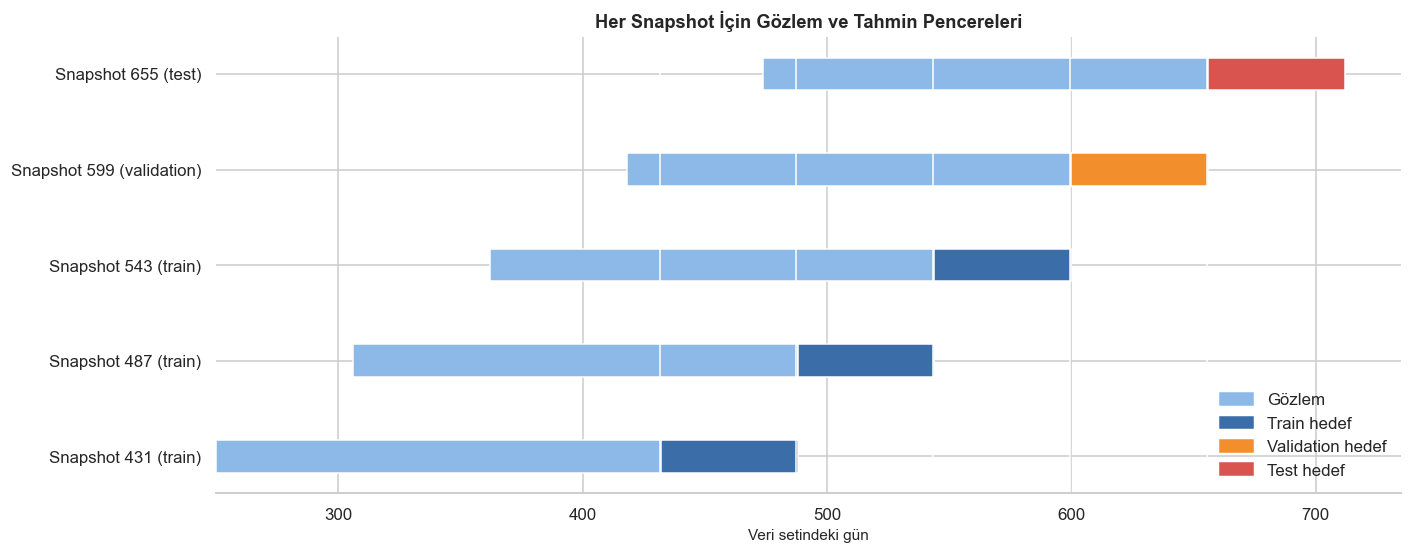

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.2))
split_colors = {
    "train": COLORS["blue"],
    "validation": COLORS["orange"],
    "test": COLORS["red"],
}

for y, row in snapshot_config.iterrows():
    ax.barh(
        y,
        OBSERVATION_WINDOW_DAYS,
        left=row["observation_start"],
        height=0.34,
        color=COLORS["light_blue"],
    )
    ax.barh(
        y,
        PREDICTION_WINDOW_DAYS,
        left=row["prediction_start"],
        height=0.34,
        color=split_colors[row["dataset_split"]],
    )
    ax.axvline(row["snapshot_day"] + 0.5, color="white", linewidth=1)

ax.set_yticks(
    range(len(snapshot_config)),
    [
        f"Snapshot {row.snapshot_day} ({row.dataset_split})"
        for row in snapshot_config.itertuples(index=False)
    ],
)
ax.set_xlabel("Veri setindeki gün")
ax.set_ylabel("")
ax.set_title("Her Snapshot İçin Gözlem ve Tahmin Pencereleri")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=COLORS["light_blue"], label="Gözlem"),
        plt.Rectangle((0, 0), 1, 1, color=COLORS["blue"], label="Train hedef"),
        plt.Rectangle((0, 0), 1, 1, color=COLORS["orange"], label="Validation hedef"),
        plt.Rectangle((0, 0), 1, 1, color=COLORS["red"], label="Test hedef"),
    ],
    loc="lower right",
)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

### Duyarlılık sonucunun yorumu

84 günlük aktiflik kuralında pasif oranı 28 günlük hedefte %14,2, 56 günlük
hedefte %7,1 ve 91 günlük hedefte %4,0'dır. Tahmin penceresi uzadıkça oranının
düşmesi beklenir: hane daha uzun pencerenin herhangi bir gününde alışveriş yaparsa
`aktif` sınıfına döner. Dolayısıyla:

- 28 gün daha çok kısa süreli alışveriş sessizliğini,
- 91 gün daha kalıcı fakat çok seyrek pasifliği,
- 56 gün ise erken müdahale ile yeterli pozitif örnek arasında orta yolu

temsil eder. Bu nedenle ilk modelleme turunda 56 gün korunur.

## 7. Hedef üretim fonksiyonu

Bir hane ilgili snapshot'ta model evrenine alınmak için:

1. Son 182 günde en az iki geçerli sepet oluşturmuş olmalı.
2. İlk gözlenen geçerli sepetinden beri en az 90 gün geçmiş olmalı.
3. Snapshot'tan önceki son 84 günde en az bir geçerli sepeti bulunmalı.

Pozitif sınıf (`target_inactive=1`), sonraki 56 günde hiç geçerli sepet olmamasıdır.
Hedef dönemindeki harcama yalnızca kalite kontrolü için hesaplanır ve model
feature'larına aktarılmaz.

In [9]:
def build_target_snapshot(
    cutoff_day,
    prediction_days,
    active_lookback_days,
    observation_days=OBSERVATION_WINDOW_DAYS,
    min_history_days=MIN_HISTORY_DAYS,
    min_baskets=MIN_BASKETS_IN_OBSERVATION,
):
    observation_start = cutoff_day - observation_days + 1
    prediction_start = cutoff_day + 1
    prediction_end = cutoff_day + prediction_days

    if observation_start < DATA_FIRST_DAY or prediction_end > DATA_LAST_DAY:
        raise ValueError(
            f"Cutoff {cutoff_day} için pencere veri sınırlarını aşıyor."
        )

    past_all = valid_basket_events.loc[
        valid_basket_events["day"].le(cutoff_day)
    ]
    observation = valid_basket_events.loc[
        valid_basket_events["day"].between(
            observation_start, cutoff_day, inclusive="both"
        )
    ]
    future = valid_basket_events.loc[
        valid_basket_events["day"].between(
            prediction_start, prediction_end, inclusive="both"
        )
    ]

    first_seen = (
        past_all.groupby("household_key")["day"]
        .min()
        .rename("first_valid_purchase_day")
    )
    profile = (
        observation.groupby("household_key")
        .agg(
            first_purchase_in_observation=("day", "min"),
            last_purchase_in_observation=("day", "max"),
            observed_baskets=("basket_id", "nunique"),
            observed_purchase_days=("day", "nunique"),
        )
        .join(first_seen, how="left")
        .reset_index()
    )

    profile["recency_at_snapshot"] = (
        cutoff_day - profile["last_purchase_in_observation"]
    )
    profile["history_days_at_snapshot"] = (
        cutoff_day - profile["first_valid_purchase_day"] + 1
    )

    future_activity = (
        future.groupby("household_key")
        .agg(
            future_baskets=("basket_id", "nunique"),
            future_purchase_days=("day", "nunique"),
            future_customer_spend=("basket_customer_spend_raw", "sum"),
        )
        .reset_index()
    )

    target = profile.merge(
        future_activity,
        on="household_key",
        how="left",
        validate="one_to_one",
    )
    future_columns = [
        "future_baskets", "future_purchase_days", "future_customer_spend"
    ]
    target[future_columns] = target[future_columns].fillna(0)
    target["target_inactive"] = target["future_baskets"].eq(0).astype("int8")

    eligibility = (
        target["observed_baskets"].ge(min_baskets)
        & target["history_days_at_snapshot"].ge(min_history_days)
    )
    if active_lookback_days is not None:
        eligibility &= target["recency_at_snapshot"].le(active_lookback_days)

    target = target.loc[eligibility].copy()
    target["snapshot_day"] = cutoff_day
    target["observation_start_day"] = observation_start
    target["prediction_start_day"] = prediction_start
    target["prediction_end_day"] = prediction_end

    return target

## 8. Hedef ve aktiflik eşiği duyarlılık analizi

Bu analiz iki ayrı kararı görünür kılar:

- **Tahmin ufku:** Kaç gün hiç alışveriş olmaması pasiflik sayılacak?
- **Aktiflik lookback'i:** Tahmin anında ne kadar yakın zamana kadar aktif olan
  haneler puanlanacak?

Karar yalnızca pozitif sınıf sayısını artırmak için verilmemelidir. Sınıf oranı,
örneklem büyüklüğü ve işletmenin müdahale süresi birlikte değerlendirilmelidir.
Karşılaştırmanın adil olması için bütün alternatifler aynı referans cutoff'ta
hesaplanır.

In [10]:
SENSITIVITY_REFERENCE_CUTOFF = 620
PREDICTION_DAY_OPTIONS = [28, 56, 91]
LOOKBACK_OPTIONS = [28, 56, 84, 112, None]

sensitivity_records = []
for prediction_days in PREDICTION_DAY_OPTIONS:
    for lookback_days in LOOKBACK_OPTIONS:
        candidate = build_target_snapshot(
            cutoff_day=SENSITIVITY_REFERENCE_CUTOFF,
            prediction_days=prediction_days,
            active_lookback_days=lookback_days,
        )
        inactive_count = int(candidate["target_inactive"].sum())
        sensitivity_records.append({
            "reference_cutoff": SENSITIVITY_REFERENCE_CUTOFF,
            "prediction_days": prediction_days,
            "active_lookback": (
                "Filtre yok" if lookback_days is None else f"{lookback_days} gün"
            ),
            "lookback_days": np.nan if lookback_days is None else lookback_days,
            "eligible_households": len(candidate),
            "inactive_households": inactive_count,
            "active_households": len(candidate) - inactive_count,
            "inactive_rate": candidate["target_inactive"].mean(),
        })

target_sensitivity = pd.DataFrame(sensitivity_records)
display(target_sensitivity)

,reference_cutoff,prediction_days,active_lookback,lookback_days,eligible_households,inactive_households,active_households,inactive_rate
0,620,28,28 gün,28.000,2027,207,1820,0.102
1,620,28,56 gün,56.000,2210,288,1922,0.130
2,620,28,84 gün,84.000,2277,324,1953,0.142
3,620,28,112 gün,112.000,2313,342,1971,0.148
4,620,28,Filtre yok,NaN,2344,360,1984,0.154
5,620,56,28 gün,28.000,2027,89,1938,0.044
6,620,56,56 gün,56.000,2210,138,2072,0.062
7,620,56,84 gün,84.000,2277,161,2116,0.071
8,620,56,112 gün,112.000,2313,173,2140,0.075
9,620,56,Filtre yok,NaN,2344,184,2160,0.078


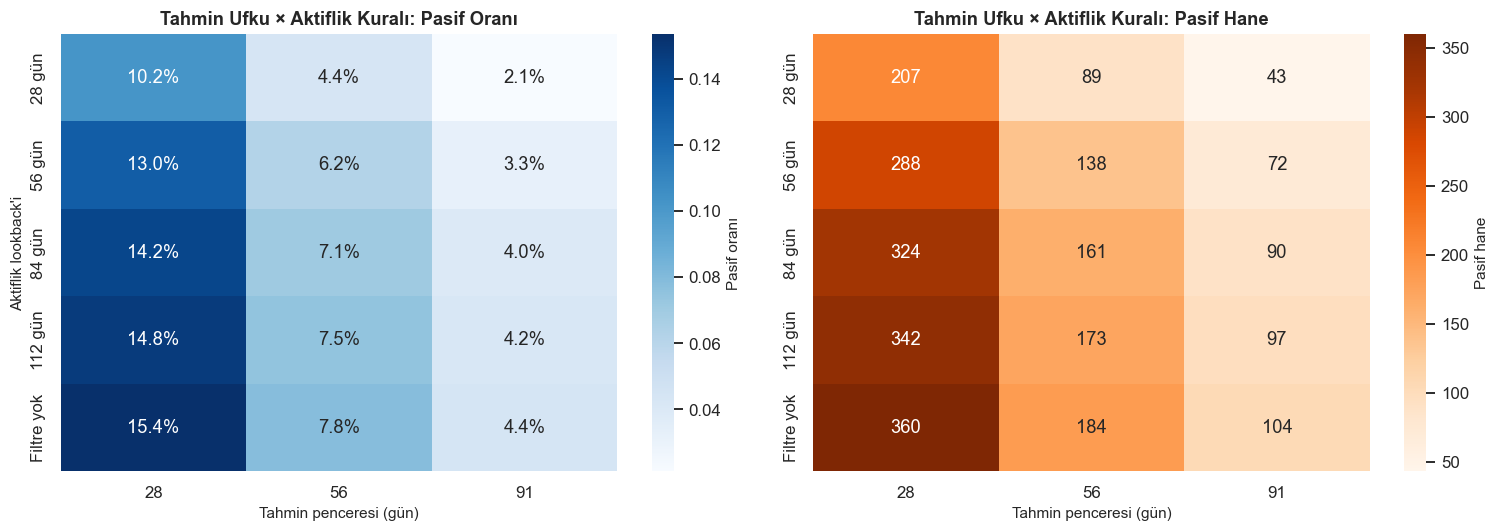

In [11]:
lookback_order = ["28 gün", "56 gün", "84 gün", "112 gün", "Filtre yok"]
rate_pivot = (
    target_sensitivity.pivot(
        index="active_lookback", columns="prediction_days", values="inactive_rate"
    )
    .reindex(lookback_order)
)
count_pivot = (
    target_sensitivity.pivot(
        index="active_lookback",
        columns="prediction_days",
        values="inactive_households",
    )
    .reindex(lookback_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    rate_pivot,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    cbar_kws={"label": "Pasif oranı"},
    ax=axes[0],
)
axes[0].set_title("Tahmin Ufku × Aktiflik Kuralı: Pasif Oranı")
axes[0].set_xlabel("Tahmin penceresi (gün)")
axes[0].set_ylabel("Aktiflik lookback'i")

sns.heatmap(
    count_pivot,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    cbar_kws={"label": "Pasif hane"},
    ax=axes[1],
)
axes[1].set_title("Tahmin Ufku × Aktiflik Kuralı: Pasif Hane")
axes[1].set_xlabel("Tahmin penceresi (gün)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Başlangıç kararı

İlk modelleme sürümünde 26 haftalık gözlem, 8 haftalık tahmin ve 12 haftalık
aktiflik lookback'i kullanılacaktır. Bu kararın gerekçeleri:

- 8 hafta, pazarlama müdahalesi açısından 91 günden daha erken aksiyon sağlar.
- Birden fazla ve çakışmayan hedef dönemi üretmeye uygundur.
- Yakın dönem seyrekleşmesini ölçmek için 26 haftalık geçmiş yeterli bağlam sunar.
- 84 günlük lookback, çoktan uzun süredir kayıp olan haneler ile yakın zamanda
  aktif olup pasifleşme riski taşıyan haneleri ayırır.

Bu değerler sonuçlara bakılarak değiştirilebilir; ancak test döneminin performansı
görüldükten sonra hedef tanımı değiştirilmemelidir.

## 9. Çoklu snapshot hedef paneli

In [12]:
target_frames = []
for snapshot_day in SNAPSHOT_DAYS:
    snapshot_target = build_target_snapshot(
        cutoff_day=snapshot_day,
        prediction_days=PREDICTION_WINDOW_DAYS,
        active_lookback_days=ACTIVE_LOOKBACK_DAYS,
    )
    snapshot_target["dataset_split"] = (
        "train" if snapshot_day in TRAIN_SNAPSHOT_DAYS
        else "validation" if snapshot_day in VALIDATION_SNAPSHOT_DAYS
        else "test"
    )
    target_frames.append(snapshot_target)

target_panel_detailed = pd.concat(target_frames, ignore_index=True)

assert not target_panel_detailed.duplicated(
    ["household_key", "snapshot_day"]
).any()
assert target_panel_detailed["target_inactive"].nunique() == 2
classes_per_split = target_panel_detailed.groupby("dataset_split")[
    "target_inactive"
].nunique()
assert classes_per_split.eq(2).all(), (
    "Train/validation/test bölümlerinin her birinde iki hedef sınıfı da bulunmalıdır. "
    f"Bulunan sınıf sayıları: {classes_per_split.to_dict()}"
)

target_snapshot_summary = (
    target_panel_detailed.groupby(["snapshot_day", "dataset_split"])
    .agg(
        households=("household_key", "nunique"),
        inactive_households=("target_inactive", "sum"),
    )
    .reset_index()
)
target_snapshot_summary["inactive_rate"] = (
    target_snapshot_summary["inactive_households"]
    / target_snapshot_summary["households"]
)
target_snapshot_summary

,snapshot_day,dataset_split,households,inactive_households,inactive_rate
0,431,train,2255,138,0.061
1,487,train,2276,150,0.066
2,543,train,2273,135,0.059
3,599,validation,2268,150,0.066
4,655,test,2284,165,0.072


In [13]:
target_split_summary = (
    target_panel_detailed.groupby("dataset_split", observed=True)
    .agg(
        household_snapshot_rows=("household_key", "size"),
        unique_households=("household_key", "nunique"),
        inactive_rows=("target_inactive", "sum"),
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)
target_split_summary["inactive_rate"] = (
    target_split_summary["inactive_rows"]
    / target_split_summary["household_snapshot_rows"]
)
target_split_summary["majority_accuracy_baseline"] = (
    1 - target_split_summary["inactive_rate"]
)
target_split_summary["random_pr_auc_baseline"] = (
    target_split_summary["inactive_rate"]
)
target_split_summary

,dataset_split,household_snapshot_rows,unique_households,inactive_rows,inactive_rate,majority_accuracy_baseline,random_pr_auc_baseline
0,train,6804,2381,423,0.062,0.938,0.062
1,validation,2268,2268,150,0.066,0.934,0.066
2,test,2284,2284,165,0.072,0.928,0.072


### Panel tekrarları ve model doğrulama sözleşmesi

Aynı hane farklı snapshot günlerinde yeniden yer alabildiği için panel satırları
bağımsız değildir. Bu durum tek başına veri sızıntısı değildir: amaç mevcut haneleri
farklı tarihlerde yeniden puanlamaktır ve feature'lar her zaman ilgili cutoff'ta
kesilir. Ancak 6.804 train satırını rastgele `KFold`/`StratifiedKFold` ile bölmek,
aynı hanenin örtüşen 182 günlük geçmişe sahip çok benzer satırlarını iki tarafa
dağıtarak performansı olduğundan yüksek gösterebilir.

Notebook 06 için ana protokol:

1. Birincil model seçimi kronolojik snapshot ayrımıyla yapılır: train günleri
   `431/487/543`, validation günü `599`, test günü `655`.
2. Train içinde ek tuning gerekiyorsa rastgele satır CV yerine snapshot bazlı
   ileri-zincirleme kullanılmalıdır (`431 → 487`, ardından `431+487 → 543`).
3. `GroupKFold(household_key)` aynı haneyi fold'lar arasında ayırır fakat zaman
   sırasını tek başına korumaz; bu nedenle ancak **yeni/hiç görülmemiş hane**
   genellemesini ölçen ikincil bir sağlamlık analizi olarak kullanılmalıdır.
4. Nihai test yalnızca bir kez, tüm seçimler validation üzerinde dondurulduktan
   sonra açılmalıdır.

In [14]:
train_household_snapshot_counts = (
    target_panel_detailed.loc[
        target_panel_detailed["dataset_split"].eq("train")
    ]
    .groupby("household_key")
    .size()
)
train_household_multiplicity = (
    train_household_snapshot_counts.value_counts()
    .sort_index()
    .rename_axis("train_snapshot_count")
    .rename("households")
    .reset_index()
)

split_households = {
    split_name: set(
        target_panel_detailed.loc[
            target_panel_detailed["dataset_split"].eq(split_name),
            "household_key",
        ]
    )
    for split_name in ["train", "validation", "test"]
}
split_household_overlap = pd.DataFrame([
    {
        "split_1": split_1,
        "split_2": split_2,
        "overlap_households": len(
            split_households[split_1] & split_households[split_2]
        ),
        "overlap_rate_of_split_2": len(
            split_households[split_1] & split_households[split_2]
        ) / len(split_households[split_2]),
    }
    for split_1, split_2 in [
        ("train", "validation"),
        ("train", "test"),
        ("validation", "test"),
    ]
])

display(train_household_multiplicity)
display(split_household_overlap)

,train_snapshot_count,households
0,1,84
1,2,171
2,3,2126


,split_1,split_2,overlap_households,overlap_rate_of_split_2
0,train,validation,2240,0.988
1,train,test,2238,0.980
2,validation,test,2204,0.965


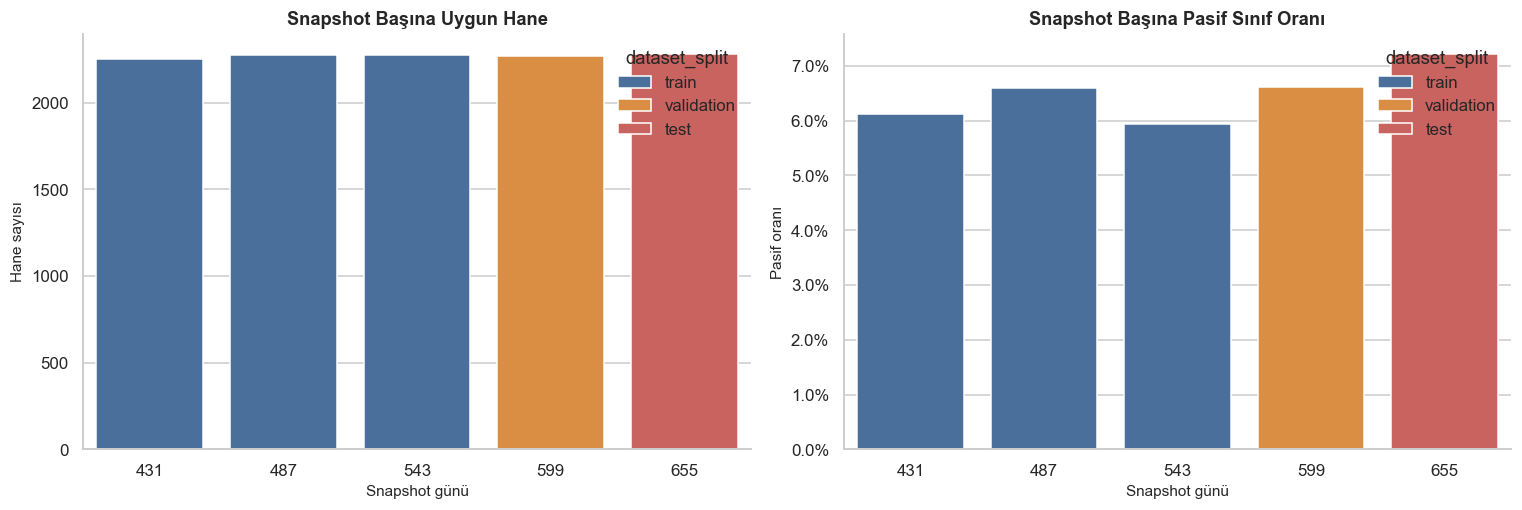

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(
    data=target_snapshot_summary,
    x="snapshot_day",
    y="households",
    hue="dataset_split",
    palette=split_colors,
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("Snapshot Başına Uygun Hane")
axes[0].set_xlabel("Snapshot günü")
axes[0].set_ylabel("Hane sayısı")

sns.barplot(
    data=target_snapshot_summary,
    x="snapshot_day",
    y="inactive_rate",
    hue="dataset_split",
    palette=split_colors,
    dodge=False,
    ax=axes[1],
)
axes[1].set_title("Snapshot Başına Pasif Sınıf Oranı")
axes[1].set_xlabel("Snapshot günü")
axes[1].set_ylabel("Pasif oranı")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Sınıf dağılımı nasıl okunmalı?

Pozitif sınıf oranının snapshot'lar arasında değişmesi beklenebilir. Bu değişim
gerçek müşteri davranışından, kampanya/dönem koşullarından veya panel kapsamındaki
değişimden kaynaklanabilir. Bu nedenle random train/test ayrımı yerine snapshot
sırası korunur. Accuracy tek başına kullanılmaz; 06'da PR-AUC, pasif sınıf
recall/precision, F1/F2, kalibrasyon ve `recall@top-k` birlikte değerlendirilir.

Bu çalıştırmada snapshot başına yaklaşık 2.255–2.284 hane kalmış ve pasif oranı
%5,9–%7,2 aralığında seyretmiştir. Validation'da 150, testte 165 pozitif satır
vardır. Bu sayılar model değerlendirmesi için kullanılabilir olsa da PR-AUC,
recall ve `recall@top-k` tek bir kesin sayı gibi yorumlanmamalıdır. Notebook 06,
validation'da seçilen sabit karar kuralıyla nihai test metrikleri için tercihen
en az 1.000 tekrarlı %95 bootstrap güven aralığı raporlamalıdır. Test snapshot'ında
her hane tek satır olduğundan bootstrap birimi hane satırıdır; her tekrar içinde
sıralama ve top-k kümesi yeniden oluşturulmalıdır.

## 10. Feature üretim ilkeleri

1. Bütün işlem tabanlı feature'lar yalnızca ilgili snapshot'ın son 182 gününden gelir.
2. Müşteri harcamasında `customer_paid_value` kullanılır.
3. Ham `quantity`, akaryakıtın farklı ölçü sistemi nedeniyle genel feature yapılmaz.
4. Ürün/kategori feature'ları kupon muhasebe satırlarını içermez.
5. Sayım, oran ve recency aynı kavramlar değildir; birlikte fakat kontrollü kullanılır.
6. Feature grupları ayrı oluşturulup yalnızca hane × snapshot seviyesinde birleştirilir.
7. Feature şeması ve kalite kararları validation/test'e bakılmadan eğitim döneminde kurulur.

In [16]:
KEYS = ["household_key", "snapshot_day"]


def safe_ratio(numerator, denominator):
    denominator_array = np.asarray(denominator, dtype="float64")
    denominator_array = np.where(denominator_array == 0, np.nan, denominator_array)
    return numerator / denominator_array


def safe_change(current, previous):
    return (current - previous) / (previous.abs() + 1)


def safe_column_name(value, prefix=""):
    cleaned = re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")
    return f"{prefix}{cleaned}"


def base_keys(cohort):
    return cohort[KEYS].drop_duplicates().copy()


def validate_feature_frame(dataframe, frame_name, expected_rows):
    assert not dataframe.duplicated(KEYS).any(), (
        f"{frame_name}: household_key × snapshot_day benzersiz değil."
    )
    assert len(dataframe) == expected_rows, (
        f"{frame_name}: beklenen {expected_rows}, bulunan {len(dataframe)} satır."
    )


def get_snapshot_sources(cutoff_day, cohort):
    observation_start = cutoff_day - OBSERVATION_WINDOW_DAYS + 1
    household_ids = cohort["household_key"]

    obs_transactions = transactions.loc[
        transactions["household_key"].isin(household_ids)
        & transactions["day"].between(
            observation_start, cutoff_day, inclusive="both"
        )
    ].copy()
    obs_transactions["relative_week"] = (
        (cutoff_day - obs_transactions["day"]) // 7
    ).astype(int)

    obs_baskets = valid_basket_events.loc[
        valid_basket_events["household_key"].isin(household_ids)
        & valid_basket_events["day"].between(
            observation_start, cutoff_day, inclusive="both"
        )
    ].copy()
    obs_baskets["relative_week"] = (
        (cutoff_day - obs_baskets["day"]) // 7
    ).astype(int)

    product_transactions = obs_transactions.loc[
        obs_transactions["is_purchase_line"]
        & ~obs_transactions["is_coupon_accounting_line"]
    ].merge(
        product[
            [
                "product_id", "department", "commodity_desc",
                "sub_commodity_desc", "brand", "manufacturer",
            ]
        ],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
    for column in PRODUCT_MODEL_TEXT_COLUMNS:
        product_transactions[column] = normalize_missing_text(
            product_transactions[column]
        )

    return obs_transactions, obs_baskets, product_transactions

## 11. RFM, aktiflik ve indirim feature'ları

Buradaki RFM metrikleri bütün veri döneminden değil, her snapshot'ın sabit
182 günlük gözlem penceresinden hesaplanır. Böylece eski ve yeni hanelerin toplam
harcama/sepet değerleri daha karşılaştırılabilir olur.

`discount_dependency`, müşterinin indirim öncesi tahmini alışveriş değerinin ne
kadarının indirimlerle karşılandığını gösterir:

\[
Discount\ Dependency =
\frac{Toplam\ İndirim}{Müşteri\ Ödemesi + Toplam\ İndirim}
\]

Bu oran kampanya kârlılığı değildir; müşterinin indirim desteğine ilişkin davranışsal
bir göstergedir.

`discounted_line_rate` ve `coupon_line_rate` yalnızca gerçek ürün satın alma
satırları üzerinden hesaplanır. Ayrı kupon muhasebe satırları bu oranların paydasını
değiştirmez. Kuponun sepette bulunup bulunmadığı ise ayrıca
`coupon_basket_rate` ile ölçülür; bu gösterge ayrı kupon satırlarını da doğru
sepete dahil eder.

In [17]:
def build_rfm_features(cutoff_day, cohort, obs_transactions, obs_baskets, product_transactions):
    base = base_keys(cohort)

    transaction_agg = (
        obs_transactions.groupby("household_key")
        .agg(
            customer_spend_total=("customer_paid_value", "sum"),
            retailer_revenue_total=("retailer_revenue", "sum"),
            unique_stores=("store_id", "nunique"),
            total_retail_discount=("retail_discount_amount", "sum"),
            total_coupon_discount=("coupon_discount_amount", "sum"),
            total_coupon_match_discount=("coupon_match_discount_amount", "sum"),
            total_discount_amount=("total_discount_amount", "sum"),
            discounted_line_rate=("purchase_line_has_any_discount", "mean"),
            coupon_line_rate=("purchase_line_has_coupon_discount", "mean"),
            coupon_accounting_line_rate=("is_coupon_accounting_line", "mean"),
        )
        .reset_index()
    )

    basket_agg = (
        obs_baskets.groupby("household_key")
        .agg(
            first_purchase_day=("day", "min"),
            last_purchase_day=("day", "max"),
            frequency_baskets=("basket_id", "nunique"),
            active_days=("day", "nunique"),
            active_weeks=("relative_week", "nunique"),
        )
        .reset_index()
    )

    product_agg = (
        product_transactions.groupby("household_key")["product_id"]
        .nunique()
        .rename("unique_products")
        .reset_index()
    )

    first_ever_purchase = (
        valid_basket_events.loc[valid_basket_events["day"].le(cutoff_day)]
        .groupby("household_key")["day"]
        .min()
        .rename("first_ever_purchase_day")
        .reset_index()
    )

    features = (
        base.merge(transaction_agg, on="household_key", how="left", validate="one_to_one")
        .merge(basket_agg, on="household_key", how="left", validate="one_to_one")
        .merge(product_agg, on="household_key", how="left", validate="one_to_one")
        .merge(first_ever_purchase, on="household_key", how="left", validate="one_to_one")
    )

    features["recency_days"] = cutoff_day - features["last_purchase_day"]
    features["purchase_span_days"] = (
        features["last_purchase_day"] - features["first_purchase_day"] + 1
    )
    features["panel_tenure_days"] = (
        cutoff_day - features["first_ever_purchase_day"] + 1
    )
    features["active_week_ratio"] = (
        features["active_weeks"] / np.ceil(OBSERVATION_WINDOW_DAYS / 7)
    ).clip(0, 1)
    features["spend_per_active_week"] = safe_ratio(
        features["customer_spend_total"], features["active_weeks"]
    )
    features["baskets_per_active_week"] = safe_ratio(
        features["frequency_baskets"], features["active_weeks"]
    )
    estimated_regular_value = (
        features["customer_spend_total"] + features["total_discount_amount"]
    )
    features["discount_dependency"] = safe_ratio(
        features["total_discount_amount"], estimated_regular_value
    )

    features = features.drop(
        columns=["first_purchase_day", "last_purchase_day", "first_ever_purchase_day"]
    )
    return features

## 12. Sepet, mağaza ve alışveriş saati feature'ları

Sepet büyüklüğünde ham `quantity` yerine müşteri ödeme tutarı ve benzersiz ürün
sayısı kullanılır. Benzin miktarının market adedinden farklı bir ölçü sistemiyle
tutulması nedeniyle toplam quantity feature'ı üretilmez.

Negatif veya sıfır müşteri ödemeli geçerli sepetler otomatik silinmez. Tutar
feature'larında sıfıra sınırlandırılmış değer, ayrıca `nonpositive_basket_rate`
göstergesi kullanılır. Böylece az sayıdaki muhasebesel sepet ortalamayı bozmaz,
ancak davranış bilgisi kaybolmaz.

In [18]:
def build_basket_features(cutoff_day, cohort, obs_transactions, obs_baskets):
    base = base_keys(cohort)
    working = obs_transactions.copy()
    working["product_for_count"] = working["product_id"].where(
        working["is_purchase_line"] & ~working["is_coupon_accounting_line"]
    )

    basket_level = (
        working.groupby(["household_key", "basket_id"], as_index=False)
        .agg(
            day=("day", "first"),
            store_id=("store_id", "first"),
            transaction_hour=("transaction_hour", "median"),
            has_purchase_line=("is_purchase_line", "max"),
            basket_customer_spend_raw=("customer_paid_value", "sum"),
            basket_unique_products=("product_for_count", "nunique"),
            basket_discount_amount=("total_discount_amount", "sum"),
            has_any_discount=("has_any_discount", "max"),
            has_coupon_discount=("has_coupon_discount", "max"),
        )
    )
    basket_level = basket_level.loc[basket_level["has_purchase_line"]].copy()
    basket_level["basket_customer_spend"] = (
        basket_level["basket_customer_spend_raw"].clip(lower=0)
    )
    basket_level["nonpositive_basket"] = (
        basket_level["basket_customer_spend_raw"].le(0)
    )
    basket_level["single_product_basket"] = basket_level["basket_unique_products"].eq(1)
    basket_level["night_basket"] = basket_level["transaction_hour"].between(0, 5)
    basket_level["morning_basket"] = basket_level["transaction_hour"].between(6, 11)
    basket_level["afternoon_basket"] = basket_level["transaction_hour"].between(12, 16)
    basket_level["evening_basket"] = basket_level["transaction_hour"].between(17, 23)

    features = (
        basket_level.groupby("household_key")
        .agg(
            avg_basket_value=("basket_customer_spend", "mean"),
            median_basket_value=("basket_customer_spend", "median"),
            basket_value_std=("basket_customer_spend", "std"),
            max_basket_value=("basket_customer_spend", "max"),
            avg_products_per_basket=("basket_unique_products", "mean"),
            median_products_per_basket=("basket_unique_products", "median"),
            products_per_basket_std=("basket_unique_products", "std"),
            single_product_basket_rate=("single_product_basket", "mean"),
            nonpositive_basket_rate=("nonpositive_basket", "mean"),
            discounted_basket_rate=("has_any_discount", "mean"),
            coupon_basket_rate=("has_coupon_discount", "mean"),
            avg_basket_discount=("basket_discount_amount", "mean"),
            avg_transaction_hour=("transaction_hour", "mean"),
            transaction_hour_std=("transaction_hour", "std"),
            night_basket_rate=("night_basket", "mean"),
            morning_basket_rate=("morning_basket", "mean"),
            afternoon_basket_rate=("afternoon_basket", "mean"),
            evening_basket_rate=("evening_basket", "mean"),
        )
        .reset_index()
    )
    features["basket_value_cv"] = safe_ratio(
        features["basket_value_std"], features["avg_basket_value"]
    )

    store_counts = (
        basket_level.groupby(["household_key", "store_id"])["basket_id"]
        .nunique()
        .rename("store_baskets")
        .reset_index()
    )
    store_concentration = (
        store_counts.groupby("household_key")["store_baskets"]
        .max()
        .rename("dominant_store_baskets")
        .reset_index()
    )
    basket_counts = (
        basket_level.groupby("household_key")["basket_id"]
        .nunique()
        .rename("basket_count_for_store_share")
        .reset_index()
    )
    store_concentration = store_concentration.merge(
        basket_counts, on="household_key", validate="one_to_one"
    )
    store_concentration["dominant_store_share"] = safe_ratio(
        store_concentration["dominant_store_baskets"],
        store_concentration["basket_count_for_store_share"],
    )
    store_concentration = store_concentration[
        ["household_key", "dominant_store_share"]
    ]

    features = (
        base.merge(features, on="household_key", how="left", validate="one_to_one")
        .merge(
            store_concentration,
            on="household_key",
            how="left",
            validate="one_to_one",
        )
    )
    return features

## 13. Alışveriş aralığı ve ritim feature'ları

Recency bütün müşteriler için aynı mutlak sessizliği ölçer; ancak müşterilerin
normal alışveriş ritimleri farklıdır. `recency_to_typical_gap`, mevcut sessizliği
hanenin kendi medyan alışveriş aralığına oranlar.

Yeni eklenen ritim göstergeleri:

- `recent_mean_purchase_gap_3`: Son üç alışveriş aralığının ortalaması
- `gap_acceleration`: Son aralık ile tarihsel medyan aralık farkı
- `gap_trend_last_5`: Son beş aralığın doğrusal eğimi
- `recent_gap_to_history_ratio`: Son üç aralığın tarihsel ortalamaya oranı

Pozitif değerli gap trendi, alışverişlerin giderek seyrekleştiğine işaret eder.

In [19]:
def summarize_purchase_gaps(days):
    unique_days = np.sort(pd.Series(days).dropna().unique())
    gaps = np.diff(unique_days).astype(float)

    if len(gaps) == 0:
        return {
            "gap_observation_count": 0,
            "mean_purchase_gap": np.nan,
            "median_purchase_gap": np.nan,
            "std_purchase_gap": np.nan,
            "max_purchase_gap": np.nan,
            "last_purchase_gap": np.nan,
            "recent_mean_purchase_gap_3": np.nan,
            "gap_trend_last_5": np.nan,
        }

    recent_gaps = gaps[-3:]
    trend_gaps = gaps[-5:]
    gap_trend = np.nan
    if len(trend_gaps) >= 2:
        x = np.arange(len(trend_gaps), dtype=float)
        gap_trend = np.polyfit(x, trend_gaps, 1)[0]

    return {
        "gap_observation_count": len(gaps),
        "mean_purchase_gap": gaps.mean(),
        "median_purchase_gap": np.median(gaps),
        "std_purchase_gap": gaps.std(ddof=1) if len(gaps) >= 2 else np.nan,
        "max_purchase_gap": gaps.max(),
        "last_purchase_gap": gaps[-1],
        "recent_mean_purchase_gap_3": recent_gaps.mean(),
        "gap_trend_last_5": gap_trend,
    }


def build_gap_features(cutoff_day, cohort, obs_baskets, rfm_features):
    base = base_keys(cohort)
    purchase_days = (
        obs_baskets[["household_key", "day"]]
        .drop_duplicates()
        .sort_values(["household_key", "day"])
    )

    records = []
    for household_key, group in purchase_days.groupby("household_key", sort=False):
        record = {"household_key": household_key}
        record.update(summarize_purchase_gaps(group["day"]))
        records.append(record)

    gap_features = pd.DataFrame(records)
    features = base.merge(
        gap_features, on="household_key", how="left", validate="one_to_one"
    )
    recency_map = rfm_features.set_index("household_key")["recency_days"]
    features["recency_days_for_gap"] = recency_map.reindex(
        features["household_key"]
    ).to_numpy()
    features["gap_cv"] = safe_ratio(
        features["std_purchase_gap"], features["mean_purchase_gap"]
    )
    features["recency_to_typical_gap"] = safe_ratio(
        features["recency_days_for_gap"], features["median_purchase_gap"]
    )
    features["gap_acceleration"] = (
        features["last_purchase_gap"] - features["median_purchase_gap"]
    )
    features["recent_gap_to_history_ratio"] = safe_ratio(
        features["recent_mean_purchase_gap_3"],
        features["mean_purchase_gap"],
    )
    features = features.drop(columns="recency_days_for_gap")
    return features

## 14. Yakın dönem seviye, değişim ve oynaklık feature'ları

Pasifleşme açısından yaşam boyu toplamdan çok yakın dönem düşüşü önemlidir. Her
snapshot için son 4, 8 ve 12 hafta ile son 8 haftadan hemen önceki 8 hafta
karşılaştırılır.

Ek olarak son 12 haftalık haftalık sepet ve harcama serilerinden:

- Doğrusal eğim,
- Standart sapma,
- Değişim katsayısı

üretilir. Böylece yalnızca düşüş yönü değil, davranışın ne kadar oynak olduğu da
ölçülür.

Değişim feature'larında önceki dönem sıfırken sonsuz değer üretmemek için
`(güncel - önceki) / (|önceki| + 1)` biçiminde düzenlenmiş değişim kullanılır.
Pay olarak yorumlanan feature'larda ise yapay `+1` eklenmez; payda sıfırsa değer
`NaN` bırakılır ve 06'daki pipeline içinde ele alınır.

In [20]:
WINDOW_SPECS = {
    "last_4w": (28, 0),
    "last_8w": (56, 0),
    "last_12w": (84, 0),
    "prev_8w": (56, 56),
}


def aggregate_window(
    cutoff_day,
    cohort,
    obs_transactions,
    obs_baskets,
    product_transactions,
    window_days,
    offset_days,
    suffix,
):
    end_day = cutoff_day - offset_days
    start_day = end_day - window_days + 1
    base = base_keys(cohort)[["household_key", "snapshot_day"]]

    tx_window = obs_transactions.loc[
        obs_transactions["day"].between(start_day, end_day, inclusive="both")
    ]
    basket_window = obs_baskets.loc[
        obs_baskets["day"].between(start_day, end_day, inclusive="both")
    ]
    product_window = product_transactions.loc[
        product_transactions["day"].between(start_day, end_day, inclusive="both")
    ]

    tx_agg = (
        tx_window.groupby("household_key")
        .agg(
            customer_spend=("customer_paid_value", "sum"),
            discounted_line_rate=("purchase_line_has_any_discount", "mean"),
            coupon_line_rate=("purchase_line_has_coupon_discount", "mean"),
        )
        .reset_index()
    )
    basket_agg = (
        basket_window.groupby("household_key")
        .agg(
            baskets=("basket_id", "nunique"),
            active_days=("day", "nunique"),
            active_weeks=("relative_week", "nunique"),
            avg_basket_value=("basket_customer_spend", "mean"),
            discounted_basket_rate=("has_any_discount", "mean"),
            coupon_basket_rate=("has_coupon_discount", "mean"),
        )
        .reset_index()
    )
    product_agg = (
        product_window.groupby("household_key")
        .agg(
            unique_products=("product_id", "nunique"),
            unique_departments=("department", "nunique"),
        )
        .reset_index()
    )

    aggregated = (
        base.merge(tx_agg, on="household_key", how="left", validate="one_to_one")
        .merge(basket_agg, on="household_key", how="left", validate="one_to_one")
        .merge(product_agg, on="household_key", how="left", validate="one_to_one")
    )
    metric_columns = [column for column in aggregated.columns if column not in KEYS]
    aggregated[metric_columns] = aggregated[metric_columns].fillna(0)
    aggregated = aggregated.rename(
        columns={column: f"{column}_{suffix}" for column in metric_columns}
    )
    return aggregated


def matrix_slope(matrix):
    x = np.arange(matrix.shape[1], dtype=float)
    x_centered = x - x.mean()
    denominator = np.square(x_centered).sum()
    return matrix.to_numpy().dot(x_centered) / denominator


def build_trend_features(
    cutoff_day, cohort, obs_transactions, obs_baskets, product_transactions, rfm_features
):
    features = base_keys(cohort)

    for suffix, (window_days, offset_days) in WINDOW_SPECS.items():
        window_features = aggregate_window(
            cutoff_day,
            cohort,
            obs_transactions,
            obs_baskets,
            product_transactions,
            window_days,
            offset_days,
            suffix,
        )
        features = features.merge(
            window_features, on=KEYS, how="left", validate="one_to_one"
        )

    features["spend_change_8w"] = safe_change(
        features["customer_spend_last_8w"],
        features["customer_spend_prev_8w"],
    )
    features["basket_change_8w"] = safe_change(
        features["baskets_last_8w"], features["baskets_prev_8w"]
    )
    features["active_week_change_8w"] = safe_change(
        features["active_weeks_last_8w"], features["active_weeks_prev_8w"]
    )
    features["product_diversity_change_8w"] = safe_change(
        features["unique_products_last_8w"],
        features["unique_products_prev_8w"],
    )
    features["department_diversity_change_8w_ratio"] = safe_change(
        features["unique_departments_last_8w"],
        features["unique_departments_prev_8w"],
    )
    features["avg_basket_value_change_8w"] = safe_change(
        features["avg_basket_value_last_8w"],
        features["avg_basket_value_prev_8w"],
    )
    features["discounted_line_rate_change_8w"] = (
        features["discounted_line_rate_last_8w"]
        - features["discounted_line_rate_prev_8w"]
    )
    features["coupon_line_rate_change_8w"] = (
        features["coupon_line_rate_last_8w"]
        - features["coupon_line_rate_prev_8w"]
    )
    features["discounted_basket_rate_change_8w"] = (
        features["discounted_basket_rate_last_8w"]
        - features["discounted_basket_rate_prev_8w"]
    )
    features["coupon_basket_rate_change_8w"] = (
        features["coupon_basket_rate_last_8w"]
        - features["coupon_basket_rate_prev_8w"]
    )

    spend_prev_4w = (
        features["customer_spend_last_8w"]
        - features["customer_spend_last_4w"]
    )
    baskets_prev_4w = (
        features["baskets_last_8w"] - features["baskets_last_4w"]
    )
    features["spend_change_4w"] = safe_change(
        features["customer_spend_last_4w"], spend_prev_4w
    )
    features["basket_change_4w"] = safe_change(
        features["baskets_last_4w"], baskets_prev_4w
    )

    total_spend_map = rfm_features.set_index("household_key")["customer_spend_total"]
    features["recent_spend_share_8w"] = safe_ratio(
        features["customer_spend_last_8w"],
        total_spend_map.reindex(features["household_key"]).to_numpy(),
    )

    recent_baskets = obs_baskets.loc[obs_baskets["relative_week"].between(0, 11)]
    weekly = (
        recent_baskets.groupby(["household_key", "relative_week"])
        .agg(
            weekly_spend=("basket_customer_spend", "sum"),
            weekly_baskets=("basket_id", "nunique"),
        )
        .reset_index()
    )
    chronological_weeks = list(range(11, -1, -1))
    household_index = features["household_key"]
    spend_matrix = (
        weekly.pivot(
            index="household_key", columns="relative_week", values="weekly_spend"
        )
        .reindex(index=household_index, columns=chronological_weeks)
        .fillna(0)
    )
    basket_matrix = (
        weekly.pivot(
            index="household_key", columns="relative_week", values="weekly_baskets"
        )
        .reindex(index=household_index, columns=chronological_weeks)
        .fillna(0)
    )

    weekly_features = pd.DataFrame({
        "household_key": household_index.to_numpy(),
        "snapshot_day": cutoff_day,
        "spend_slope_12w": matrix_slope(spend_matrix),
        "basket_slope_12w": matrix_slope(basket_matrix),
        "weekly_spend_std_12w": spend_matrix.std(axis=1, ddof=1).to_numpy(),
        "weekly_basket_std_12w": basket_matrix.std(axis=1, ddof=1).to_numpy(),
        "weekly_spend_mean_12w": spend_matrix.mean(axis=1).to_numpy(),
        "weekly_basket_mean_12w": basket_matrix.mean(axis=1).to_numpy(),
    })
    weekly_features["weekly_spend_cv_12w"] = safe_ratio(
        weekly_features["weekly_spend_std_12w"],
        weekly_features["weekly_spend_mean_12w"],
    )
    weekly_features["weekly_basket_cv_12w"] = safe_ratio(
        weekly_features["weekly_basket_std_12w"],
        weekly_features["weekly_basket_mean_12w"],
    )

    features = features.merge(
        weekly_features, on=KEYS, how="left", validate="one_to_one"
    )
    return features

## 15. Ürün, kategori, marka ve özel işlem feature'ları

### Kategori karması

Kategori paylarında `retailer_revenue` kullanılır. Bunun nedeni üretici kuponunun
bazen üründen ayrı bir muhasebe satırında bulunmasıdır; müşteri ödeme tutarını
kategoriye zorla dağıtmak yanlış eşleştirme yaratabilir. Buna karşılık RFM ve sepet
tutarlarında müşteri ödemesi kullanılmaya devam eder.

### Feature şemasının eğitim döneminde kurulması

Departman sütunları bütün veri dönemine bakılarak seçilmez. İlk sekiz departman
yalnızca train snapshot'larının erişebildiği işlem geçmişinden belirlenir ve
validation/test için aynı şema kullanılır.

### Yakıt ve özel işlemler

Yakıt miktarı kullanılmaz; bunun yerine yakıt harcama payı, yakıt sepet oranı ve
son yakıt alışverişinden geçen gün üretilir. `fuel`, `gift/ticket` ve `other_misc`
sınıfları öncelik sırasıyla ve birbirini dışlayacak biçimde tanımlanır.

In [21]:
TRAIN_SCHEMA_START_DAY = min(TRAIN_SNAPSHOT_DAYS) - OBSERVATION_WINDOW_DAYS + 1
TRAIN_SCHEMA_END_DAY = max(TRAIN_SNAPSHOT_DAYS)

training_product_schema = (
    transactions.loc[
        transactions["day"].between(
            TRAIN_SCHEMA_START_DAY, TRAIN_SCHEMA_END_DAY, inclusive="both"
        )
        & transactions["is_purchase_line"]
        & ~transactions["is_coupon_accounting_line"]
    ]
    .merge(
        product[["product_id", "department"]],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
)
training_product_schema["department"] = normalize_missing_text(
    training_product_schema["department"]
)

schema_source_days = training_product_schema["day"].dropna()
training_schema_audit = pd.Series({
    "source_rows": int(len(training_product_schema)),
    "actual_min_day": int(schema_source_days.min()),
    "actual_max_day": int(schema_source_days.max()),
    "allowed_min_day": int(TRAIN_SCHEMA_START_DAY),
    "allowed_max_day": int(TRAIN_SCHEMA_END_DAY),
    "all_source_rows_within_train_accessible_range": bool(
        schema_source_days.between(
            TRAIN_SCHEMA_START_DAY,
            TRAIN_SCHEMA_END_DAY,
            inclusive="both",
        ).all()
    ),
})
assert training_schema_audit[
    "all_source_rows_within_train_accessible_range"
], "Departman şeması train erişim aralığı dışından satır içeriyor."

TOP_DEPARTMENT_COUNT = 8
TOP_DEPARTMENTS = (
    training_product_schema.groupby("department")["retailer_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_DEPARTMENT_COUNT)
    .index
    .tolist()
)

display(training_schema_audit.to_frame("value"))
print("Yalnızca train döneminden seçilen departmanlar:")
display(pd.DataFrame({"department": TOP_DEPARTMENTS}))

,value
source_rows,1173743
actual_min_day,250
actual_max_day,543
allowed_min_day,250
allowed_max_day,543
all_source_rows_within_train_accessible_range,True


Yalnızca train döneminden seçilen departmanlar:


,department
0,GROCERY
1,DRUG GM
2,KIOSK-GAS
3,PRODUCE
4,MEAT
5,MEAT-PCKGD
6,DELI
7,MISC SALES TRAN


In [22]:
def add_product_type_flags(product_transactions):
    dataframe = product_transactions.copy()
    department = dataframe["department"].str.strip().str.upper()
    commodity = dataframe["commodity_desc"].str.strip().str.upper()
    subcommodity = dataframe["sub_commodity_desc"].str.strip().str.upper()

    dataframe["is_fuel"] = (
        department.str.contains(r"KIOSK-GAS|FUEL", regex=True, na=False)
        | subcommodity.str.contains("GASOLINE", regex=False, na=False)
    )
    dataframe["is_gift_or_ticket"] = (
        ~dataframe["is_fuel"]
        & (
            commodity.str.contains("TICKET", regex=False, na=False)
            | subcommodity.str.contains(r"GIFT CARD|TICKET", regex=True, na=False)
        )
    )
    dataframe["is_other_misc"] = (
        ~dataframe["is_fuel"]
        & ~dataframe["is_gift_or_ticket"]
        & (
            department.str.contains("MISC", regex=False, na=False)
            | commodity.isin(["NO COMMODITY DESCRIPTION", "COUPON/MISC ITEMS"])
        )
    )
    return dataframe


def build_category_change_features(cutoff_day, cohort, product_transactions):
    base = base_keys(cohort)
    current_start = cutoff_day - 56 + 1
    previous_start = cutoff_day - 112 + 1
    previous_end = cutoff_day - 56
    pair_columns = ["household_key", "department"]

    current_pairs = (
        product_transactions.loc[
            product_transactions["day"].between(
                current_start, cutoff_day, inclusive="both"
            ),
            pair_columns,
        ]
        .drop_duplicates()
    )
    previous_pairs = (
        product_transactions.loc[
            product_transactions["day"].between(
                previous_start, previous_end, inclusive="both"
            ),
            pair_columns,
        ]
        .drop_duplicates()
    )

    current_counts = (
        current_pairs.groupby("household_key")["department"]
        .nunique()
        .rename("departments_last_8w")
        .reset_index()
    )
    previous_counts = (
        previous_pairs.groupby("household_key")["department"]
        .nunique()
        .rename("departments_prev_8w")
        .reset_index()
    )
    common_counts = (
        previous_pairs.merge(current_pairs, on=pair_columns, how="inner")
        .groupby("household_key")
        .size()
        .rename("common_departments_8w")
        .reset_index()
    )
    lost_counts = (
        previous_pairs.merge(
            current_pairs, on=pair_columns, how="left", indicator=True
        )
        .loc[lambda frame: frame["_merge"].eq("left_only")]
        .groupby("household_key")
        .size()
        .rename("lost_departments_8w")
        .reset_index()
    )
    new_counts = (
        current_pairs.merge(
            previous_pairs, on=pair_columns, how="left", indicator=True
        )
        .loc[lambda frame: frame["_merge"].eq("left_only")]
        .groupby("household_key")
        .size()
        .rename("new_departments_8w")
        .reset_index()
    )

    features = base.copy()
    for frame in [
        current_counts, previous_counts, common_counts, lost_counts, new_counts
    ]:
        features = features.merge(
            frame, on="household_key", how="left", validate="one_to_one"
        )

    count_columns = [
        "departments_last_8w", "departments_prev_8w",
        "common_departments_8w", "lost_departments_8w", "new_departments_8w",
    ]
    features[count_columns] = features[count_columns].fillna(0).astype(int)
    features["department_diversity_change_8w"] = (
        features["departments_last_8w"] - features["departments_prev_8w"]
    )
    union_count = (
        features["departments_last_8w"]
        + features["departments_prev_8w"]
        - features["common_departments_8w"]
    )
    features["has_previous_department_history"] = (
        features["departments_prev_8w"].gt(0).astype("int8")
    )
    features["department_retention_rate"] = safe_ratio(
        features["common_departments_8w"], features["departments_prev_8w"]
    )
    features["department_jaccard"] = safe_ratio(
        features["common_departments_8w"], union_count
    )
    return features


def build_product_features(cutoff_day, cohort, obs_baskets, product_transactions):
    base = base_keys(cohort)
    working = add_product_type_flags(product_transactions)

    diversity = (
        working.groupby("household_key")
        .agg(
            unique_departments=("department", "nunique"),
            unique_commodities=("commodity_desc", "nunique"),
            unique_subcommodities=("sub_commodity_desc", "nunique"),
        )
        .reset_index()
    )

    product_baskets = (
        working.groupby(["household_key", "product_id"])["basket_id"]
        .nunique()
        .rename("product_baskets")
        .reset_index()
    )
    repeat_product = (
        product_baskets.assign(
            repeated_product=lambda frame: frame["product_baskets"].ge(2)
        )
        .groupby("household_key")["repeated_product"]
        .mean()
        .rename("repeat_product_rate")
        .reset_index()
    )

    department_revenue = (
        working.groupby(["household_key", "department"], as_index=False)[
            "retailer_revenue"
        ]
        .sum()
        .rename(columns={"retailer_revenue": "department_revenue"})
    )
    department_revenue = department_revenue.loc[
        department_revenue["department_revenue"].gt(0)
    ].copy()
    department_revenue["household_product_revenue"] = (
        department_revenue.groupby("household_key")["department_revenue"]
        .transform("sum")
    )
    department_revenue["department_share"] = safe_ratio(
        department_revenue["department_revenue"],
        department_revenue["household_product_revenue"],
    )
    department_revenue["hhi_component"] = department_revenue["department_share"].pow(2)
    department_revenue["entropy_component"] = np.where(
        department_revenue["department_share"].gt(0),
        -department_revenue["department_share"]
        * np.log(department_revenue["department_share"]),
        0,
    )

    concentration = (
        department_revenue.groupby("household_key")
        .agg(
            top_department_revenue_share=("department_share", "max"),
            department_hhi=("hhi_component", "sum"),
            department_entropy_raw=("entropy_component", "sum"),
            positive_revenue_department_count=("department", "nunique"),
        )
        .reset_index()
    )
    top3_share = (
        department_revenue.groupby("household_key")["department_share"]
        .apply(lambda series: series.nlargest(3).sum())
        .rename("top3_department_revenue_share")
        .reset_index()
    )
    concentration = concentration.merge(
        top3_share, on="household_key", validate="one_to_one"
    )
    entropy_denominator = np.log(
        concentration["positive_revenue_department_count"].clip(lower=2)
    )
    concentration["department_entropy"] = np.where(
        concentration["positive_revenue_department_count"].gt(1),
        concentration["department_entropy_raw"] / entropy_denominator,
        0,
    )
    concentration = concentration.drop(
        columns=["department_entropy_raw", "positive_revenue_department_count"]
    )

    top_department_pivot = (
        department_revenue.loc[
            department_revenue["department"].isin(TOP_DEPARTMENTS)
        ]
        .pivot(index="household_key", columns="department", values="department_share")
        .reindex(columns=TOP_DEPARTMENTS)
        .fillna(0)
    )
    top_department_pivot.columns = [
        safe_column_name(column, prefix="dept_revenue_share_")
        for column in top_department_pivot.columns
    ]
    top_department_features = top_department_pivot.reset_index()

    brand = working["brand"].str.strip().str.lower()
    working["private_revenue"] = working["retailer_revenue"].where(
        brand.eq("private"), 0
    )
    working["fuel_revenue"] = working["retailer_revenue"].where(
        working["is_fuel"], 0
    )
    working["fuel_day"] = working["day"].where(working["is_fuel"])
    working["gift_ticket_revenue"] = working["retailer_revenue"].where(
        working["is_gift_or_ticket"], 0
    )
    working["other_misc_revenue"] = working["retailer_revenue"].where(
        working["is_other_misc"], 0
    )

    preference = (
        working.groupby("household_key")
        .agg(
            product_revenue_total=("retailer_revenue", "sum"),
            private_revenue=("private_revenue", "sum"),
            fuel_revenue=("fuel_revenue", "sum"),
            gift_ticket_revenue=("gift_ticket_revenue", "sum"),
            other_misc_revenue=("other_misc_revenue", "sum"),
            fuel_purchase_days=("fuel_day", "nunique"),
        )
        .reset_index()
    )
    for numerator, feature_name in {
        "private_revenue": "private_brand_revenue_share",
        "fuel_revenue": "fuel_revenue_share",
        "gift_ticket_revenue": "gift_ticket_revenue_share",
        "other_misc_revenue": "other_misc_revenue_share",
    }.items():
        preference[feature_name] = safe_ratio(
            preference[numerator], preference["product_revenue_total"]
        ).fillna(0)

    fuel_baskets = (
        working.loc[working["is_fuel"]]
        .groupby("household_key")["basket_id"]
        .nunique()
        .rename("fuel_baskets")
        .reset_index()
    )
    last_fuel_day = (
        working.loc[working["is_fuel"]]
        .groupby("household_key")["day"]
        .max()
        .rename("last_fuel_day")
        .reset_index()
    )
    total_baskets = (
        obs_baskets.groupby("household_key")["basket_id"]
        .nunique()
        .rename("total_valid_baskets")
        .reset_index()
    )
    fuel_behavior = (
        total_baskets.merge(
            fuel_baskets, on="household_key", how="left", validate="one_to_one"
        )
        .merge(
            last_fuel_day, on="household_key", how="left", validate="one_to_one"
        )
    )
    fuel_behavior["fuel_baskets"] = fuel_behavior["fuel_baskets"].fillna(0)
    fuel_behavior["has_fuel_purchase"] = fuel_behavior["fuel_baskets"].gt(0).astype("int8")
    fuel_behavior["fuel_basket_rate"] = safe_ratio(
        fuel_behavior["fuel_baskets"], fuel_behavior["total_valid_baskets"]
    )
    fuel_behavior["days_since_last_fuel_purchase"] = (
        cutoff_day - fuel_behavior["last_fuel_day"]
    )
    fuel_behavior = fuel_behavior[
        [
            "household_key", "has_fuel_purchase", "fuel_basket_rate",
            "days_since_last_fuel_purchase",
        ]
    ]

    category_change = build_category_change_features(
        cutoff_day, cohort, working
    )

    features = base.copy()
    for frame in [
        diversity,
        repeat_product,
        concentration,
        top_department_features,
        preference[
            [
                "household_key", "private_brand_revenue_share",
                "fuel_revenue_share", "gift_ticket_revenue_share",
                "other_misc_revenue_share", "fuel_purchase_days",
            ]
        ],
        fuel_behavior,
    ]:
        features = features.merge(
            frame, on="household_key", how="left", validate="one_to_one"
        )
    features = features.merge(
        category_change, on=KEYS, how="left", validate="one_to_one"
    )

    zero_fill_columns = [
        column for column in features.columns
        if column.startswith("dept_revenue_share_")
    ] + [
        "private_brand_revenue_share", "fuel_revenue_share",
        "gift_ticket_revenue_share", "other_misc_revenue_share",
        "fuel_purchase_days", "has_fuel_purchase", "fuel_basket_rate",
    ]
    features[zero_fill_columns] = features[zero_fill_columns].fillna(0)
    return features

## 16. Kampanya ve kupon feature'ları

Kampanya kayıtları snapshot'a göre üçe ayrılır:

| Durum | Kullanım |
|---|---|
| `end_day <= snapshot` | Tamamlanmış kampanya sayısı ve tipleri |
| `start_day <= snapshot < end_day` | Aktif kampanya sayısı |
| Snapshot'tan sonra başlayan | Kullanılmaz |

Kupon kullanımlarında iki farklı kavram korunur:

- Gözlem penceresindeki gerçek kullanım davranışı
- Tamamlanmış Type B/C kampanyalarındaki bilinen kupon fırsatlarına göre kullanım

Type A kampanyalarında haneye gönderilen 16 kuponun kimliği bilinmediği için Type A
kupon fırsatı paydası kurulmaz. Type A için yalnızca kampanya alma ve fiilî kullanım
sayısı gibi güvenilir göstergeler kullanılır.

In [23]:
campaign_assignments = (
    campaign_table[["household_key", "campaign"]]
    .drop_duplicates()
    .merge(
        campaign_desc[["campaign", "description", "start_day", "end_day"]],
        on="campaign",
        how="left",
        validate="many_to_one",
    )
)

redemptions_enriched = coupon_redempt.merge(
    campaign_desc[["campaign", "description", "start_day", "end_day"]],
    on="campaign",
    how="left",
    validate="many_to_one",
)
redemptions_enriched["within_campaign_window"] = redemptions_enriched["day"].between(
    redemptions_enriched["start_day"],
    redemptions_enriched["end_day"],
    inclusive="both",
)
assert redemptions_enriched["within_campaign_window"].all()

campaign_coupon_counts = (
    coupon.groupby("campaign")["coupon_upc"]
    .nunique()
    .rename("distinct_coupon_opportunities")
    .reset_index()
)
CAMPAIGN_TYPES = sorted(campaign_desc["description"].dropna().unique())

In [24]:
def build_campaign_features(cutoff_day, cohort):
    base = base_keys(cohort)
    household_ids = cohort["household_key"]
    observation_start = cutoff_day - OBSERVATION_WINDOW_DAYS + 1

    assignments = campaign_assignments.loc[
        campaign_assignments["household_key"].isin(household_ids)
    ].copy()
    completed = assignments.loc[assignments["end_day"].le(cutoff_day)].copy()
    active = assignments.loc[
        assignments["start_day"].le(cutoff_day)
        & assignments["end_day"].gt(cutoff_day)
    ].copy()
    recent_started = assignments.loc[
        assignments["start_day"].between(
            observation_start, cutoff_day, inclusive="both"
        )
    ].copy()

    completed_summary = (
        completed.groupby("household_key")
        .agg(
            completed_campaigns_received=("campaign", "nunique"),
            last_completed_campaign_end=("end_day", "max"),
        )
        .reset_index()
    )
    completed_by_type = (
        completed.pivot_table(
            index="household_key",
            columns="description",
            values="campaign",
            aggfunc="nunique",
            fill_value=0,
        )
        .reindex(columns=CAMPAIGN_TYPES, fill_value=0)
        .add_prefix("completed_campaigns_received_")
        .reset_index()
    )
    active_summary = (
        active.groupby("household_key")["campaign"]
        .nunique()
        .rename("active_campaigns_at_snapshot")
        .reset_index()
    )
    recent_summary = (
        recent_started.groupby("household_key")["campaign"]
        .nunique()
        .rename("campaigns_started_last_26w")
        .reset_index()
    )

    observed_redemptions = redemptions_enriched.loc[
        redemptions_enriched["household_key"].isin(household_ids)
        & redemptions_enriched["day"].between(
            observation_start, cutoff_day, inclusive="both"
        )
    ].copy()
    all_past_redemptions = redemptions_enriched.loc[
        redemptions_enriched["household_key"].isin(household_ids)
        & redemptions_enriched["day"].le(cutoff_day)
    ].copy()

    redemption_summary = (
        observed_redemptions.groupby("household_key")
        .agg(
            coupon_redemption_events_obs=("coupon_upc", "size"),
            unique_coupons_redeemed_obs=("coupon_upc", "nunique"),
            campaigns_with_redemption_obs=("campaign", "nunique"),
        )
        .reset_index()
    )
    last_redemption = (
        all_past_redemptions.groupby("household_key")["day"]
        .max()
        .rename("last_redemption_day")
        .reset_index()
    )
    redemption_by_type = (
        observed_redemptions.pivot_table(
            index="household_key",
            columns="description",
            values="coupon_upc",
            aggfunc="size",
            fill_value=0,
        )
        .reindex(columns=CAMPAIGN_TYPES, fill_value=0)
        .add_prefix("coupon_redemption_events_obs_")
        .reset_index()
    )

    completed_bc = completed.loc[
        completed["description"].isin(["TypeB", "TypeC"])
    ].merge(
        campaign_coupon_counts,
        on="campaign",
        how="left",
        validate="many_to_one",
    )
    bc_opportunities = (
        completed_bc.groupby("household_key")["distinct_coupon_opportunities"]
        .sum()
        .rename("bc_coupon_opportunities_completed")
        .reset_index()
    )
    completed_bc_ids = set(completed_bc["campaign"])
    redeemed_bc = (
        all_past_redemptions.loc[
            all_past_redemptions["campaign"].isin(completed_bc_ids)
            & all_past_redemptions["description"].isin(["TypeB", "TypeC"])
        ]
        .drop_duplicates(["household_key", "campaign", "coupon_upc"])
        .groupby("household_key")
        .agg(
            bc_unique_coupon_redemptions_completed=("coupon_upc", "size"),
            bc_campaigns_with_redemption_completed=("campaign", "nunique"),
        )
        .reset_index()
    )

    completed_redemptions = all_past_redemptions.loc[
        all_past_redemptions["campaign"].isin(set(completed["campaign"]))
    ]
    completed_redemption_campaigns = (
        completed_redemptions.groupby("household_key")["campaign"]
        .nunique()
        .rename("completed_campaigns_with_redemption")
        .reset_index()
    )

    features = base.copy()
    for frame in [
        completed_summary, completed_by_type, active_summary, recent_summary,
        redemption_summary, last_redemption, redemption_by_type,
        bc_opportunities, redeemed_bc, completed_redemption_campaigns,
    ]:
        features = features.merge(
            frame, on="household_key", how="left", validate="one_to_one"
        )

    count_columns = [
        column for column in features.columns
        if column.startswith("completed_campaigns_received")
        or column.startswith("coupon_redemption_events_obs")
        or column in {
            "active_campaigns_at_snapshot", "campaigns_started_last_26w",
            "unique_coupons_redeemed_obs", "campaigns_with_redemption_obs",
            "bc_coupon_opportunities_completed",
            "bc_unique_coupon_redemptions_completed",
            "bc_campaigns_with_redemption_completed",
            "completed_campaigns_with_redemption",
        }
    ]
    features[count_columns] = features[count_columns].fillna(0)

    features["has_campaign_history"] = (
        features["completed_campaigns_received"].gt(0).astype("int8")
    )
    features["has_active_campaign"] = (
        features["active_campaigns_at_snapshot"].gt(0).astype("int8")
    )
    features["has_redeemed_coupon"] = (
        features["coupon_redemption_events_obs"].gt(0).astype("int8")
    )
    features["has_bc_coupon_opportunity"] = (
        features["bc_coupon_opportunities_completed"].gt(0).astype("int8")
    )
    features["days_since_last_campaign"] = (
        cutoff_day - features["last_completed_campaign_end"]
    )
    features["days_since_last_redemption"] = (
        cutoff_day - features["last_redemption_day"]
    )
    features["redemption_campaign_share"] = safe_ratio(
        features["completed_campaigns_with_redemption"],
        features["completed_campaigns_received"],
    )
    features["bc_coupon_redemption_rate"] = safe_ratio(
        features["bc_unique_coupon_redemptions_completed"],
        features["bc_coupon_opportunities_completed"],
    )
    features = features.drop(
        columns=["last_completed_campaign_end", "last_redemption_day"]
    )
    return features

## 17. Demografi feature'ları ve deney stratejisi

Demografi yalnızca hanelerin bir bölümünde bulunur ve önceki EDA, demografi kaydı
olan hanelerin daha aktif olduğunu göstermiştir. Bu nedenle:

1. Ana model davranışsal feature'larla kurulur.
2. `has_demographic` ayrı bir ek deney olarak denenir.
3. Bütün anonim demografi kategorileri başka bir ablasyon deneyinde eklenir.
4. Yalnızca demografisi olan hanelerde kurulan model, ayrı alt örneklem sonucu
   olarak raporlanır.

Demografi kaydı olmayan haneler kategorik alanlarda `NO_DEMOGRAPHIC_RECORD` olur.
Kaydı bulunan hanelerdeki `Unknown` / `None/Unknown` değerleri ise ayrı bilgi
belirsizliği olarak korunur. `demographic_unknown_count`, kaydı olmayanlarda 7
yapılmaz; `NaN` bırakılarak `has_demographic` ile birlikte yorumlanır. Kaydı
bulunduğu hâlde boş olan bir alan da `MISSING_WITHIN_DEMOGRAPHIC_RECORD` etiketiyle
ayrılır; böylece kayıt yokluğu ile alan içi eksiklik karışmaz.

In [25]:
DEMOGRAPHIC_COLUMNS = [
    column for column in hh_demographic.columns if column != "household_key"
]
DEMOGRAPHIC_META_FEATURES = [
    "demographic_unknown_count",
    "has_internal_demographic_unknown",
]
UNCERTAIN_DEMOGRAPHIC_LABELS = {
    "unknown", "none/unknown", "none", "n/a", "na", "null", ""
}


def build_demographic_features(cohort):
    features = base_keys(cohort).merge(
        hh_demographic,
        on="household_key",
        how="left",
        validate="many_to_one",
    )
    features["has_demographic"] = (
        features["household_key"].isin(hh_demographic["household_key"])
        .astype("int8")
    )

    unknown_count = pd.Series(0, index=features.index, dtype="float")
    for column in DEMOGRAPHIC_COLUMNS:
        normalized = (
            features[column].astype("string").str.strip().str.lower()
        )
        internal_unknown = (
            normalized.isna()
            | normalized.isin(UNCERTAIN_DEMOGRAPHIC_LABELS)
        ) & features["has_demographic"].eq(1)
        unknown_count = unknown_count.add(
            internal_unknown.astype(int),
            fill_value=0,
        )

    features["demographic_unknown_count"] = unknown_count.where(
        features["has_demographic"].eq(1), np.nan
    )
    features["has_internal_demographic_unknown"] = (
        features["demographic_unknown_count"].fillna(0).gt(0).astype("int8")
    )

    for column in DEMOGRAPHIC_COLUMNS:
        features[column] = features[column].astype("string")
        no_record = features["has_demographic"].eq(0)
        internal_missing = (
            features["has_demographic"].eq(1)
            & features[column].isna()
        )
        features.loc[no_record, column] = "NO_DEMOGRAPHIC_RECORD"
        features.loc[
            internal_missing, column
        ] = "MISSING_WITHIN_DEMOGRAPHIC_RECORD"
    return features

## 18. Bütün snapshot feature tablolarının oluşturulması

In [26]:
feature_group_frames = {
    "rfm": [],
    "basket_store_time": [],
    "purchase_regularity": [],
    "temporal_trend": [],
    "product_category": [],
    "campaign_coupon": [],
    "demographic": [],
}
snapshot_audit_records = []

for snapshot_day in SNAPSHOT_DAYS:
    cohort = target_panel_detailed.loc[
        target_panel_detailed["snapshot_day"].eq(snapshot_day)
    ].copy()
    obs_transactions, obs_baskets, product_transactions = get_snapshot_sources(
        snapshot_day, cohort
    )

    rfm_features = build_rfm_features(
        snapshot_day, cohort, obs_transactions, obs_baskets, product_transactions
    )
    basket_features = build_basket_features(
        snapshot_day, cohort, obs_transactions, obs_baskets
    )
    gap_features = build_gap_features(
        snapshot_day, cohort, obs_baskets, rfm_features
    )
    trend_features = build_trend_features(
        snapshot_day,
        cohort,
        obs_transactions,
        obs_baskets,
        product_transactions,
        rfm_features,
    )
    product_features = build_product_features(
        snapshot_day, cohort, obs_baskets, product_transactions
    )
    campaign_features = build_campaign_features(snapshot_day, cohort)
    demographic_features = build_demographic_features(cohort)

    snapshot_frames = {
        "rfm": rfm_features,
        "basket_store_time": basket_features,
        "purchase_regularity": gap_features,
        "temporal_trend": trend_features,
        "product_category": product_features,
        "campaign_coupon": campaign_features,
        "demographic": demographic_features,
    }
    for frame_name, frame in snapshot_frames.items():
        validate_feature_frame(frame, frame_name, len(cohort))
        feature_group_frames[frame_name].append(frame)

    snapshot_audit_records.append({
        "snapshot_day": snapshot_day,
        "observation_start_day": snapshot_day - OBSERVATION_WINDOW_DAYS + 1,
        "max_transaction_feature_day": int(obs_transactions["day"].max()),
        "max_basket_feature_day": int(obs_baskets["day"].max()),
        "max_product_feature_day": int(product_transactions["day"].max()),
        "prediction_start_day": snapshot_day + 1,
        "prediction_end_day": snapshot_day + PREDICTION_WINDOW_DAYS,
        "households": len(cohort),
    })

feature_frames = {
    frame_name: pd.concat(frames, ignore_index=True)
    for frame_name, frames in feature_group_frames.items()
}
snapshot_audit = pd.DataFrame(snapshot_audit_records)

for frame_name, frame in feature_frames.items():
    validate_feature_frame(frame, frame_name, len(target_panel_detailed))
    print(f"{frame_name:22} -> {frame.shape}")

rfm                    -> (11356, 23)
basket_store_time      -> (11356, 22)
purchase_regularity    -> (11356, 14)
temporal_trend         -> (11356, 67)
product_category       -> (11356, 35)
campaign_coupon        -> (11356, 26)
demographic            -> (11356, 12)


## 19. Feature tablolarının hane × snapshot seviyesinde birleştirilmesi

Ham tablolar birbirine topluca bağlanmaz. Her kaynak önce hane × snapshot seviyesine
özetlenir; ardından `validate="one_to_one"` ile birleştirilir. Bu yaklaşım kupon–ürün
ve işlem–kampanya ilişkilerinden doğabilecek satır çoğalmasını önler.

| Feature grubu | Kaynak tablolar | Ara işlem / güvenli join | Nihai anahtar |
|---|---|---|---|
| RFM, sepet, ritim, trend | `transaction_data` | Geçerli sepet ve zaman penceresi filtreleri | hane × snapshot |
| Ürün/kategori/marka/yakıt | `transaction_data` + `product` | `product_id` üzerinde `many_to_one`; kupon muhasebe satırları hariç | hane × snapshot |
| Kampanya geçmişi | `campaign_table` + `campaign_desc` | `campaign` üzerinde `many_to_one`; cutoff durumuna göre filtre | hane × snapshot |
| B/C kupon fırsatı | `campaign_table` + `coupon` | Önce kampanya başına benzersiz kupon, sonra haneye toplama | hane × snapshot |
| Kupon kullanımı | `coupon_redempt` + `campaign_desc` | Yalnızca cutoff'a kadarki geçerli kullanımlar | hane × snapshot |
| Demografi | `hh_demographic` | `household_key` üzerinde `many_to_one` left join | hane × snapshot |

`transaction_data` doğrudan kampanya veya kupon tablosuna bağlanmaz. Böyle bir
ham join aynı işlem satırını kampanyadaki kupon sayısı kadar çoğaltabilir. Nihai
birleştirmede yalnızca önceden özetlenmiş feature tabloları kullanılır.

In [27]:
target_output_columns = [
    "household_key", "snapshot_day", "observation_start_day",
    "prediction_start_day", "prediction_end_day", "dataset_split",
    "target_inactive",
]
household_snapshot_table = target_panel_detailed[target_output_columns].copy()

for frame_name, frame in feature_frames.items():
    household_snapshot_table = household_snapshot_table.merge(
        frame,
        on=KEYS,
        how="left",
        validate="one_to_one",
    )

household_snapshot_table = household_snapshot_table.replace(
    [np.inf, -np.inf], np.nan
)

assert len(household_snapshot_table) == len(target_panel_detailed)
assert not household_snapshot_table.duplicated(KEYS).any()

recency_consistency = (
    target_panel_detailed[
        KEYS + ["recency_at_snapshot"]
    ]
    .merge(
        feature_frames["rfm"][KEYS + ["recency_days"]],
        on=KEYS,
        how="inner",
        validate="one_to_one",
    )
)
recency_consistency["difference_days"] = (
    recency_consistency["recency_at_snapshot"]
    - recency_consistency["recency_days"]
)
RECENCY_MISMATCH_COUNT = int(
    recency_consistency["difference_days"].ne(0).sum()
)
assert len(recency_consistency) == len(household_snapshot_table)
assert RECENCY_MISMATCH_COUNT == 0, (
    "Target uygunluğu ile model feature'ı recency hesapları uyuşmuyor: "
    f"{RECENCY_MISMATCH_COUNT} satır."
)

METADATA_COLUMNS = {
    "household_key", "snapshot_day", "observation_start_day",
    "prediction_start_day", "prediction_end_day", "dataset_split",
    "target_inactive",
}
CATEGORICAL_FEATURES = DEMOGRAPHIC_COLUMNS.copy()
ALL_CANDIDATE_FEATURES = [
    column for column in household_snapshot_table.columns
    if column not in METADATA_COLUMNS
]

print(f"Model paneli             : {household_snapshot_table.shape}")
print(f"Hane × snapshot satırı   : {len(household_snapshot_table):,}")
print(f"Ham aday feature         : {len(ALL_CANDIDATE_FEATURES):,}")
print(f"Kategorik feature        : {len(CATEGORICAL_FEATURES):,}")
print(f"Recency uyumsuzluğu      : {RECENCY_MISMATCH_COUNT:,}")
household_snapshot_table.head()

Model paneli             : (11356, 192)
Hane × snapshot satırı   : 11,356
Ham aday feature         : 185
Kategorik feature        : 7
Recency uyumsuzluğu      : 0


,household_key,snapshot_day,observation_start_day,prediction_start_day,prediction_end_day,dataset_split,target_inactive,customer_spend_total,retailer_revenue_total,unique_stores,total_retail_discount,total_coupon_discount,total_coupon_match_discount,total_discount_amount,discounted_line_rate,coupon_line_rate,coupon_accounting_line_rate,frequency_baskets,active_days,active_weeks,unique_products,recency_days,purchase_span_days,panel_tenure_days,active_week_ratio,spend_per_active_week,baskets_per_active_week,discount_dependency,avg_basket_value,median_basket_value,basket_value_std,max_basket_value,avg_products_per_basket,median_products_per_basket,products_per_basket_std,single_product_basket_rate,nonpositive_basket_rate,discounted_basket_rate,coupon_basket_rate,avg_basket_discount,avg_transaction_hour,transaction_hour_std,night_basket_rate,morning_basket_rate,afternoon_basket_rate,evening_basket_rate,basket_value_cv,dominant_store_share,gap_observation_count,mean_purchase_gap,median_purchase_gap,std_purchase_gap,max_purchase_gap,last_purchase_gap,recent_mean_purchase_gap_3,gap_trend_last_5,gap_cv,recency_to_typical_gap,gap_acceleration,recent_gap_to_history_ratio,customer_spend_last_4w,discounted_line_rate_last_4w,coupon_line_rate_last_4w,baskets_last_4w,active_days_last_4w,active_weeks_last_4w,avg_basket_value_last_4w,discounted_basket_rate_last_4w,coupon_basket_rate_last_4w,unique_products_last_4w,unique_departments_last_4w,customer_spend_last_8w,discounted_line_rate_last_8w,coupon_line_rate_last_8w,baskets_last_8w,active_days_last_8w,active_weeks_last_8w,avg_basket_value_last_8w,discounted_basket_rate_last_8w,coupon_basket_rate_last_8w,unique_products_last_8w,unique_departments_last_8w,customer_spend_last_12w,discounted_line_rate_last_12w,coupon_line_rate_last_12w,baskets_last_12w,active_days_last_12w,active_weeks_last_12w,avg_basket_value_last_12w,discounted_basket_rate_last_12w,coupon_basket_rate_last_12w,unique_products_last_12w,unique_departments_last_12w,customer_spend_prev_8w,discounted_line_rate_prev_8w,coupon_line_rate_prev_8w,baskets_prev_8w,active_days_prev_8w,active_weeks_prev_8w,avg_basket_value_prev_8w,discounted_basket_rate_prev_8w,coupon_basket_rate_prev_8w,unique_products_prev_8w,unique_departments_prev_8w,spend_change_8w,basket_change_8w,active_week_change_8w,product_diversity_change_8w,department_diversity_change_8w_ratio,avg_basket_value_change_8w,discounted_line_rate_change_8w,coupon_line_rate_change_8w,discounted_basket_rate_change_8w,coupon_basket_rate_change_8w,spend_change_4w,basket_change_4w,recent_spend_share_8w,spend_slope_12w,basket_slope_12w,weekly_spend_std_12w,weekly_basket_std_12w,weekly_spend_mean_12w,weekly_basket_mean_12w,weekly_spend_cv_12w,weekly_basket_cv_12w,unique_departments,unique_commodities,unique_subcommodities,repeat_product_rate,top_department_revenue_share,department_hhi,top3_department_revenue_share,department_entropy,dept_revenue_share_grocery,dept_revenue_share_drug_gm,dept_revenue_share_kiosk_gas,dept_revenue_share_produce,dept_revenue_share_meat,dept_revenue_share_meat_pckgd,dept_revenue_share_deli,dept_revenue_share_misc_sales_tran,private_brand_revenue_share,fuel_revenue_share,gift_ticket_revenue_share,other_misc_revenue_share,fuel_purchase_days,has_fuel_purchase,fuel_basket_rate,days_since_last_fuel_purchase,departments_last_8w,departments_prev_8w,common_departments_8w,lost_departments_8w,new_departments_8w,department_diversity_change_8w,has_previous_department_history,department_retention_rate,department_jaccard,completed_campaigns_received,completed_campaigns_received_TypeA,completed_campaigns_received_TypeB,completed_campaigns_received_TypeC,active_campaigns_at_snapshot,campaigns_started_last_26w,coupon_redemption_events_obs,unique_coupons_redeemed_obs,campaigns_with_redemption_obs,coupon_redemption_events_obs_TypeA,coupon_redemption_events_obs_TypeB,coupon_redemption_events_obs_TypeC,bc_coupon_opportunities_completed,bc_unique_coupon_redemptions_completed,bc_campaign

## 20. Çekirdek ve genişletilmiş feature setleri

Bütün aday feature'ları ilk modele vermek yerine dört kontrollü deney seti oluşturulur:

1. **behavior_core_linear:** Logistic Regression için belirgin davranış tekrarı
   azaltılmış çekirdek set
2. **behavior_core:** Transaction, sepet, ritim ve yakın dönem trendleri; ağaç
   tabanlı modeller için tam çekirdek set
3. **behavior_plus_context:** Davranış + ürün/kategori + kampanya + demografi
   kaydı göstergesi
4. **demographic_experiment:** Context seti + anonim demografik kategoriler

Çalıştırılmış train verisinde `active_days`, hem `frequency_baskets` ile yaklaşık
0,99 hem de `active_weeks` ile yaklaşık 0,97 Spearman korelasyona sahiptir. İki
yüksek korelasyon çiftinin ortak değişkeni olduğu için yalnızca `active_days`
Logistic Regression setinden çıkarılır. `frequency_baskets` alışveriş olayı
sayısını, `active_weeks` ise alışverişin zamana yayılımını temsil ettiği için
korunur. `active_week_ratio` ise `active_weeks / 26` biçiminde matematiksel tekrar
olduğundan zaten orijinal `behavior_core` listesine alınmamıştır.

Tam `behavior_core` ağaç modellerindeki karşılaştırmalar için korunur. Logistic
Regression yine standardizasyon ve L2 düzenlileştirme içeren bir pipeline ile
kurulmalı; kalan korelasyonlar katsayı kararlılığıyla birlikte yorumlanmalıdır.

Benzer şekilde son 8 haftadaki sessiz hafta sayısı `8 - active_weeks_last_8w`
olduğundan çekirdek sete ayrıca eklenmez. Eksik recency/oran feature'ları da tek
başına kullanılmaz: `days_since_last_fuel_purchase`,
`department_retention_rate` ve `bc_coupon_redemption_rate` sırasıyla
`has_fuel_purchase`, `has_previous_department_history` ve
`has_bc_coupon_opportunity` ile eşleştirilir.

Kampanya context'i Type A/B/C kampanya ve kupon kullanım sayılarını ayrı taşır.
Böylece özellikle hedefli Type A iletişiminin ek katkısı ölçülebilir. Eğitim
döneminden seçilen ilk sekiz departmanın harcama payları da bu sete dahil edilir;
bu sütunlar validation/test verisine bakılarak seçilmez.

In [28]:
BEHAVIOR_CORE_FEATURES = [
    "recency_days",
    "frequency_baskets",
    "customer_spend_total",
    "active_days",
    "active_weeks",
    "spend_per_active_week",
    "baskets_per_active_week",
    "unique_products",
    "unique_stores",
    "discount_dependency",
    "discounted_basket_rate",
    "coupon_basket_rate",
    "median_basket_value",
    "basket_value_cv",
    "avg_products_per_basket",
    "single_product_basket_rate",
    "dominant_store_share",
    "median_purchase_gap",
    "last_purchase_gap",
    "recent_mean_purchase_gap_3",
    "gap_acceleration",
    "recency_to_typical_gap",
    "gap_trend_last_5",
    "customer_spend_last_4w",
    "baskets_last_4w",
    "active_weeks_last_4w",
    "customer_spend_last_8w",
    "baskets_last_8w",
    "active_weeks_last_8w",
    "discounted_basket_rate_last_8w",
    "coupon_basket_rate_last_8w",
    "spend_change_8w",
    "basket_change_8w",
    "avg_basket_value_change_8w",
    "spend_slope_12w",
    "basket_slope_12w",
    "weekly_spend_cv_12w",
    "weekly_basket_cv_12w",
]

LINEAR_REDUNDANT_FEATURES = {
    "active_days": (
        "frequency_baskets ile yaklaşık 0.99 ve active_weeks ile yaklaşık "
        "0.97 train Spearman korelasyon"
    ),
}
BEHAVIOR_CORE_LINEAR_FEATURES = [
    feature for feature in BEHAVIOR_CORE_FEATURES
    if feature not in LINEAR_REDUNDANT_FEATURES
]


TOP_DEPARTMENT_CONTEXT_FEATURES = [
    safe_column_name(department, prefix="dept_revenue_share_")
    for department in TOP_DEPARTMENTS
]
CAMPAIGN_TYPE_CONTEXT_FEATURES = (
    [
        f"completed_campaigns_received_{campaign_type}"
        for campaign_type in CAMPAIGN_TYPES
    ]
    + [
        f"coupon_redemption_events_obs_{campaign_type}"
        for campaign_type in CAMPAIGN_TYPES
    ]
)

CONTEXT_FEATURES = [
    "unique_departments",
    "department_hhi",
    "department_entropy",
    "top_department_revenue_share",
    "repeat_product_rate",
    "private_brand_revenue_share",
    "fuel_revenue_share",
    "fuel_basket_rate",
    "has_fuel_purchase",
    "days_since_last_fuel_purchase",
    "has_previous_department_history",
    "department_retention_rate",
    "department_jaccard",
    "has_campaign_history",
    "active_campaigns_at_snapshot",
    "campaigns_started_last_26w",
    "days_since_last_campaign",
    "has_redeemed_coupon",
    "days_since_last_redemption",
    "redemption_campaign_share",
    "has_bc_coupon_opportunity",
    "bc_coupon_opportunities_completed",
    "bc_coupon_redemption_rate",
    "has_demographic",
] + TOP_DEPARTMENT_CONTEXT_FEATURES + CAMPAIGN_TYPE_CONTEXT_FEATURES

missing_core = set(BEHAVIOR_CORE_FEATURES) - set(ALL_CANDIDATE_FEATURES)
missing_context = set(CONTEXT_FEATURES) - set(ALL_CANDIDATE_FEATURES)
missing_demographic_meta = set(DEMOGRAPHIC_META_FEATURES) - set(ALL_CANDIDATE_FEATURES)
assert not missing_core, f"Eksik behavior core feature'ları: {sorted(missing_core)}"
assert not missing_context, f"Eksik context feature'ları: {sorted(missing_context)}"
assert not missing_demographic_meta, (
    f"Eksik demografi meta feature'ları: {sorted(missing_demographic_meta)}"
)

FEATURE_SETS = {
    "behavior_core_linear": BEHAVIOR_CORE_LINEAR_FEATURES,
    "behavior_core": BEHAVIOR_CORE_FEATURES,
    "behavior_plus_context": BEHAVIOR_CORE_FEATURES + CONTEXT_FEATURES,
    "demographic_experiment": (
        BEHAVIOR_CORE_FEATURES
        + CONTEXT_FEATURES
        + DEMOGRAPHIC_META_FEATURES
        + CATEGORICAL_FEATURES
    ),
}

for feature_set_name, feature_names in FEATURE_SETS.items():
    assert len(feature_names) == len(set(feature_names)), (
        f"{feature_set_name} içinde yinelenen feature var."
    )

pd.DataFrame({
    "feature_set": list(FEATURE_SETS),
    "feature_count": [len(features) for features in FEATURE_SETS.values()],
})

,feature_set,feature_count
0,behavior_core_linear,37
1,behavior_core,38
2,behavior_plus_context,76
3,demographic_experiment,85


## 21. Eğitim dönemi üzerinden feature kalite kontrolü

Sabit feature ve korelasyon kontrolleri bütün panelde değil, yalnızca train
snapshot'larında yapılır. Validation/test dönemlerinin dağılımına bakarak feature
kararı vermek değerlendirme sızıntısı yaratır.

Eksikliklerin üç farklı anlamı olabilir:

- Kupon/kampanya/yakıt geçmişinin bulunmaması gibi davranışsal eksiklik
- Demografi kaydının bulunmaması
- Yetersiz alışveriş günü nedeniyle standart sapmanın hesaplanamaması

Bu değerler 05'te doldurulmaz; göstergeleriyle birlikte korunur.

In [29]:
train_rows = household_snapshot_table["dataset_split"].eq("train")
train_features = household_snapshot_table.loc[train_rows, ALL_CANDIDATE_FEATURES]

feature_quality = pd.DataFrame({
    "dtype": train_features.dtypes.astype(str),
    "missing_count_train": train_features.isna().sum(),
    "missing_ratio_train": train_features.isna().mean(),
    "unique_count_train": train_features.nunique(dropna=False),
})
feature_quality["quality_note"] = np.select(
    [
        feature_quality["unique_count_train"].le(1),
        feature_quality["missing_ratio_train"].ge(0.50),
        feature_quality["missing_ratio_train"].gt(0),
    ],
    [
        "Train döneminde sabit — çıkar",
        "Yüksek eksik — göstergeyle birlikte kullan",
        "Eksik — fold içi imputation",
    ],
    default="Hazır",
)
feature_quality = feature_quality.sort_values(
    ["missing_ratio_train", "unique_count_train"], ascending=[False, True]
)

CONSTANT_FEATURES_TRAIN = feature_quality.index[
    feature_quality["unique_count_train"].le(1)
].tolist()
MODELING_CANDIDATE_FEATURES = [
    feature for feature in ALL_CANDIDATE_FEATURES
    if feature not in CONSTANT_FEATURES_TRAIN
]

FEATURE_SETS = {
    name: [feature for feature in features if feature not in CONSTANT_FEATURES_TRAIN]
    for name, features in FEATURE_SETS.items()
}

print(f"Train satırı                  : {train_rows.sum():,}")
print(f"Ham aday feature             : {len(ALL_CANDIDATE_FEATURES):,}")
print(f"Train döneminde sabit        : {len(CONSTANT_FEATURES_TRAIN):,}")
print(f"Modellemeye kalan aday       : {len(MODELING_CANDIDATE_FEATURES):,}")
if CONSTANT_FEATURES_TRAIN:
    print("Çıkarılacak sabit feature'lar:", CONSTANT_FEATURES_TRAIN)

display(feature_quality.head(30))

Train satırı                  : 6,804
Ham aday feature             : 185
Train döneminde sabit        : 0
Modellemeye kalan aday       : 185


,dtype,missing_count_train,missing_ratio_train,unique_count_train,quality_note
days_since_last_redemption,float64,6084,0.894,180,Yüksek eksik — göstergeyle birlikte kullan
bc_coupon_redemption_rate,float64,4971,0.731,72,Yüksek eksik — göstergeyle birlikte kullan
demographic_unknown_count,float64,4410,0.648,4,Yüksek eksik — göstergeyle birlikte kullan
days_since_last_fuel_purchase,float64,4010,0.589,183,Yüksek eksik — göstergeyle birlikte kullan
redemption_campaign_share,float64,3511,0.516,20,Yüksek eksik — göstergeyle birlikte kullan
days_since_last_campaign,float64,3511,0.516,26,Yüksek eksik — göstergeyle birlikte kullan
department_retention_rate,float64,353,0.052,65,Eksik — fold içi imputation
gap_trend_last_5,float64,154,0.023,1815,Eksik — fold içi imputation
std_purchase_gap,float64,154,0.023,6464,Eksik — fold içi imputation
gap_cv,float64,154,0.023,6601,Eksik — fold içi imputation


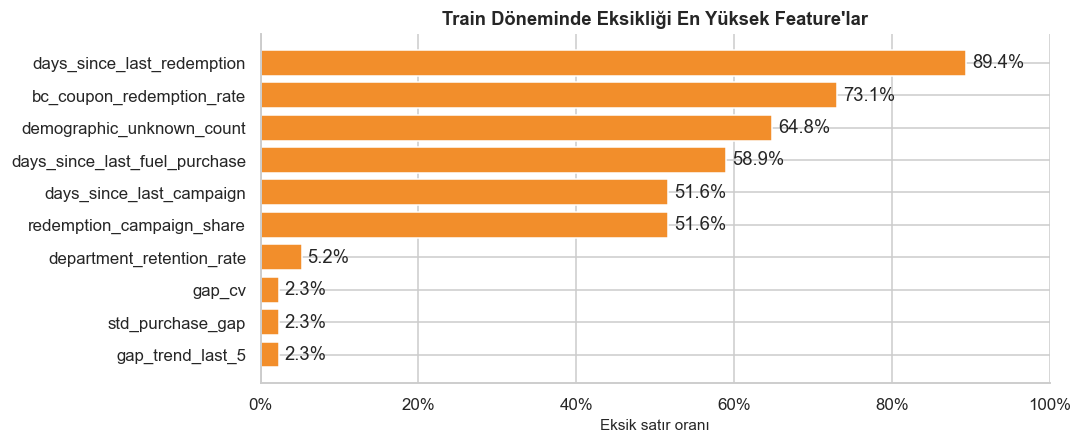

In [30]:
missing_plot = (
    feature_quality.loc[feature_quality["missing_ratio_train"].ge(0.01)]
    .head(20)
    .sort_values("missing_ratio_train")
    .reset_index(names="feature")
)

if len(missing_plot):
    fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(missing_plot))))
    bars = ax.barh(
        missing_plot["feature"],
        missing_plot["missing_ratio_train"],
        color=COLORS["orange"],
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in missing_plot["missing_ratio_train"]],
        padding=4,
    )
    ax.set_xlim(0, min(1, missing_plot["missing_ratio_train"].max() * 1.15))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Train Döneminde Eksikliği En Yüksek Feature'lar")
    ax.set_xlabel("Eksik satır oranı")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Train döneminde %1 veya üzeri eksik feature yok.")

### Korelasyon ne amaçla kullanılıyor?

Yüksek korelasyon bir feature'ın otomatik olarak hatalı olduğu anlamına gelmez.
Ancak aynı davranışın çok sayıda benzer değişkenle temsil edilmesi özellikle
lojistik regresyonda katsayı kararsızlığına yol açabilir. Bu nedenle korelasyon
yalnızca train döneminden hesaplanır.

Genel aday havuzunda otomatik eleme yapılmaz. Buna karşılık iki yüksek korelasyon
çiftinin ortak değişkeni olan `active_days`, Logistic Regression'a ayrılan
`behavior_core_linear` setinden bilinçli olarak çıkarılmıştır. Matematiksel tekrar
olan `active_week_ratio` zaten tam `behavior_core` içinde değildir. Aşağıdaki
ikinci tablo, tam `behavior_core` içindeki yüksek korelasyonları özellikle görünür
kılar; kalan ilişkiler Notebook 06'da standardizasyon, L2 düzenlileştirme ve
katsayı kararlılığıyla birlikte değerlendirilmelidir.

In [31]:
numeric_model_candidates = [
    column for column in MODELING_CANDIDATE_FEATURES
    if pd.api.types.is_numeric_dtype(household_snapshot_table[column])
]
train_numeric = household_snapshot_table.loc[train_rows, numeric_model_candidates]
numeric_correlation = train_numeric.corr(method="spearman")
upper_mask = np.triu(np.ones(numeric_correlation.shape, dtype=bool), k=1)

high_correlation_pairs = (
    numeric_correlation.where(upper_mask)
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_correlation_pairs["absolute_correlation"] = (
    high_correlation_pairs["spearman_correlation"].abs()
)
high_correlation_pairs = high_correlation_pairs.loc[
    high_correlation_pairs["absolute_correlation"].ge(0.90)
].sort_values("absolute_correlation", ascending=False)

print("Train döneminde |Spearman| ≥ 0.90 olan ilk 25 çift:")
display(high_correlation_pairs.head(25))

behavior_core_high_correlation_pairs = high_correlation_pairs.loc[
    high_correlation_pairs["feature_1"].isin(BEHAVIOR_CORE_FEATURES)
    & high_correlation_pairs["feature_2"].isin(BEHAVIOR_CORE_FEATURES)
].copy()

print("Tam behavior_core içindeki |Spearman| ≥ 0.90 çiftleri:")
display(behavior_core_high_correlation_pairs)

assert not set(LINEAR_REDUNDANT_FEATURES).intersection(
    FEATURE_SETS["behavior_core_linear"]
), "Lineer setten çıkarılması kararlaştırılan tekrarlar hâlâ listede."

Train döneminde |Spearman| ≥ 0.90 olan ilk 25 çift:


,feature_1,feature_2,spearman_correlation,absolute_correlation
2153,active_weeks,active_week_ratio,1.000,1.000
1999,active_days,gap_observation_count,1.000,1.000
17231,unique_departments_prev_8w,departments_prev_8w,1.000,1.000
13999,baskets_last_12w,weekly_basket_mean_12w,1.000,1.000
13314,unique_departments_last_8w,departments_last_8w,1.000,1.000
13464,customer_spend_last_12w,weekly_spend_mean_12w,1.000,1.000
28104,coupon_redemption_events_obs,unique_coupons_redeemed_obs,1.000,1.000
1,customer_spend_total,retailer_revenue_total,1.000,1.000
29357,bc_unique_coupon_redemptions_completed,bc_campaigns_with_redemption_completed,1.000,1.000
29366,bc_unique_coupon_redemptions_completed,bc_coupon_redemption_rate,0.999,0.999


Tam behavior_core içindeki |Spearman| ≥ 0.90 çiftleri:


,feature_1,feature_2,spearman_correlation,absolute_correlation
1791,frequency_baskets,active_days,0.994,0.994
1970,active_days,active_weeks,0.973,0.973
1792,frequency_baskets,active_weeks,0.962,0.962
13,customer_spend_total,unique_products,0.954,0.954
11995,baskets_last_8w,active_weeks_last_8w,0.941,0.941
20765,weekly_spend_cv_12w,weekly_basket_cv_12w,0.937,0.937
12399,active_weeks_last_8w,weekly_basket_cv_12w,-0.936,0.936
10035,baskets_last_4w,baskets_last_8w,0.925,0.925
10026,baskets_last_4w,active_weeks_last_4w,0.922,0.922
9498,customer_spend_last_4w,customer_spend_last_8w,0.914,0.914


## 22. Veri sızıntısı ve bütünlük denetimi

Kontroller yalnızca sütun adlarına bakmaz. Her snapshot'ta kullanılan en yüksek
işlem, basket ve ürün günü cutoff'u aşmamalıdır. Ayrıca:

- Departman şemasını oluşturan **gerçek kaynak satırlarının** günleri yalnızca
  train'in erişebildiği aralıkta kalmalı,
- Hedef uygunluğundaki `recency_at_snapshot` ile modeldeki `recency_days` her
  hane × snapshot için birebir eşleşmeli,
- `future_*`, ham kimlikler ve hedef yardımcıları model girdisine girmemeli,
- Hane × snapshot anahtarı benzersiz olmalı,
- Train/validation/test snapshot listeleri ayrık ve kronolojik olmalıdır.

In [32]:
FORBIDDEN_EXACT_FEATURES = {
    "basket_id", "product_id", "store_id", "manufacturer", "coupon_upc",
    "campaign", "target_inactive", "snapshot_day", "household_key",
    "prediction_start_day", "prediction_end_day", "dataset_split",
}
forbidden_present = sorted(
    FORBIDDEN_EXACT_FEATURES.intersection(MODELING_CANDIDATE_FEATURES)
)
future_named_features = sorted(
    feature for feature in MODELING_CANDIDATE_FEATURES
    if feature.startswith("future_")
)

leakage_checks = pd.DataFrame([
    {
        "check": "Transaction feature günleri cutoff'u aşmıyor",
        "passed": bool(
            snapshot_audit["max_transaction_feature_day"]
            .le(snapshot_audit["snapshot_day"])
            .all()
        ),
        "detail": "snapshot bazında kontrol",
    },
    {
        "check": "Basket feature günleri cutoff'u aşmıyor",
        "passed": bool(
            snapshot_audit["max_basket_feature_day"]
            .le(snapshot_audit["snapshot_day"])
            .all()
        ),
        "detail": "snapshot bazında kontrol",
    },
    {
        "check": "Ürün feature günleri cutoff'u aşmıyor",
        "passed": bool(
            snapshot_audit["max_product_feature_day"]
            .le(snapshot_audit["snapshot_day"])
            .all()
        ),
        "detail": "snapshot bazında kontrol",
    },
    {
        "check": "Hedef dönemleri cutoff'tan sonra başlıyor",
        "passed": bool(
            target_panel_detailed["prediction_start_day"]
            .gt(target_panel_detailed["snapshot_day"])
            .all()
        ),
        "detail": "prediction_start > snapshot",
    },
    {
        "check": "Departman şeması kaynak günleri train erişim aralığında",
        "passed": bool(
            training_schema_audit[
                "all_source_rows_within_train_accessible_range"
            ]
        ),
        "detail": (
            f"actual={int(training_schema_audit['actual_min_day'])}-"
            f"{int(training_schema_audit['actual_max_day'])}; "
            f"allowed={TRAIN_SCHEMA_START_DAY}-{TRAIN_SCHEMA_END_DAY}"
        ),
    },
    {
        "check": "Target ve feature recency hesapları birebir eşleşiyor",
        "passed": RECENCY_MISMATCH_COUNT == 0,
        "detail": f"mismatch={RECENCY_MISMATCH_COUNT:,}",
    },
    {
        "check": "Ham kimlikler model feature listesinde değil",
        "passed": not forbidden_present,
        "detail": str(forbidden_present),
    },
    {
        "check": "future_* sütunları model feature listesinde değil",
        "passed": not future_named_features,
        "detail": str(future_named_features),
    },
    {
        "check": "Hane × snapshot anahtarı benzersiz",
        "passed": not household_snapshot_table.duplicated(KEYS).any(),
        "detail": f"rows={len(household_snapshot_table):,}",
    },
    {
        "check": "Bütün satırlarda hedef mevcut",
        "passed": household_snapshot_table["target_inactive"].notna().all(),
        "detail": f"missing={household_snapshot_table['target_inactive'].isna().sum()}",
    },
    {
        "check": "Train/validation/test snapshot kümeleri ayrık",
        "passed": (
            set(TRAIN_SNAPSHOT_DAYS).isdisjoint(VALIDATION_SNAPSHOT_DAYS)
            and set(TRAIN_SNAPSHOT_DAYS).isdisjoint(TEST_SNAPSHOT_DAYS)
            and set(VALIDATION_SNAPSHOT_DAYS).isdisjoint(TEST_SNAPSHOT_DAYS)
        ),
        "detail": "snapshot listeleri",
    },
])

display(leakage_checks)
assert leakage_checks["passed"].all(), (
    "Veri sızıntısı veya bütünlük kontrolü başarısız."
)

,check,passed,detail
0,Transaction feature günleri cutoff'u aşmıyor,True,snapshot bazında kontrol
1,Basket feature günleri cutoff'u aşmıyor,True,snapshot bazında kontrol
2,Ürün feature günleri cutoff'u aşmıyor,True,snapshot bazında kontrol
3,Hedef dönemleri cutoff'tan sonra başlıyor,True,prediction_start > snapshot
4,Departman şeması kaynak günleri train erişim a...,True,actual=250-543; allowed=250-543
5,Target ve feature recency hesapları birebir eş...,True,mismatch=0
6,Ham kimlikler model feature listesinde değil,True,[]
7,future_* sütunları model feature listesinde değil,True,[]
8,Hane × snapshot anahtarı benzersiz,True,"rows=11,356"
9,Bütün satırlarda hedef mevcut,True,missing=0


## 23. Hedefe göre davranış karşılaştırması — yalnızca train dönemi

Bu bölüm feature seçmek için validation/test hedeflerine bakmaz. Yalnızca train
snapshot'larında, pasif hanelerin geçmiş davranışının iş beklentisiyle uyumlu olup
olmadığını kontrol eder.

Beklenen örüntü; pasif sınıfta daha yüksek recency ve alışveriş aralığı, daha düşük
yakın dönem sepet/aktif hafta ve negatif davranış trendidir. Sonuçlar nedensellik
göstermez.

target_inactive,active_median,inactive_median,inactive_minus_active
recency_days,4.000,26.000,22.000
frequency_baskets,25.000,6.000,-19.000
customer_spend_total,709.570,137.790,-571.780
median_purchase_gap,6.000,15.000,9.000
recency_to_typical_gap,0.667,1.406,0.740
active_weeks_last_8w,5.000,1.000,-4.000
customer_spend_last_8w,214.340,26.740,-187.600
baskets_last_8w,8.000,2.000,-6.000
spend_change_8w,0.015,-0.066,-0.081
basket_change_8w,0.000,0.000,0.000


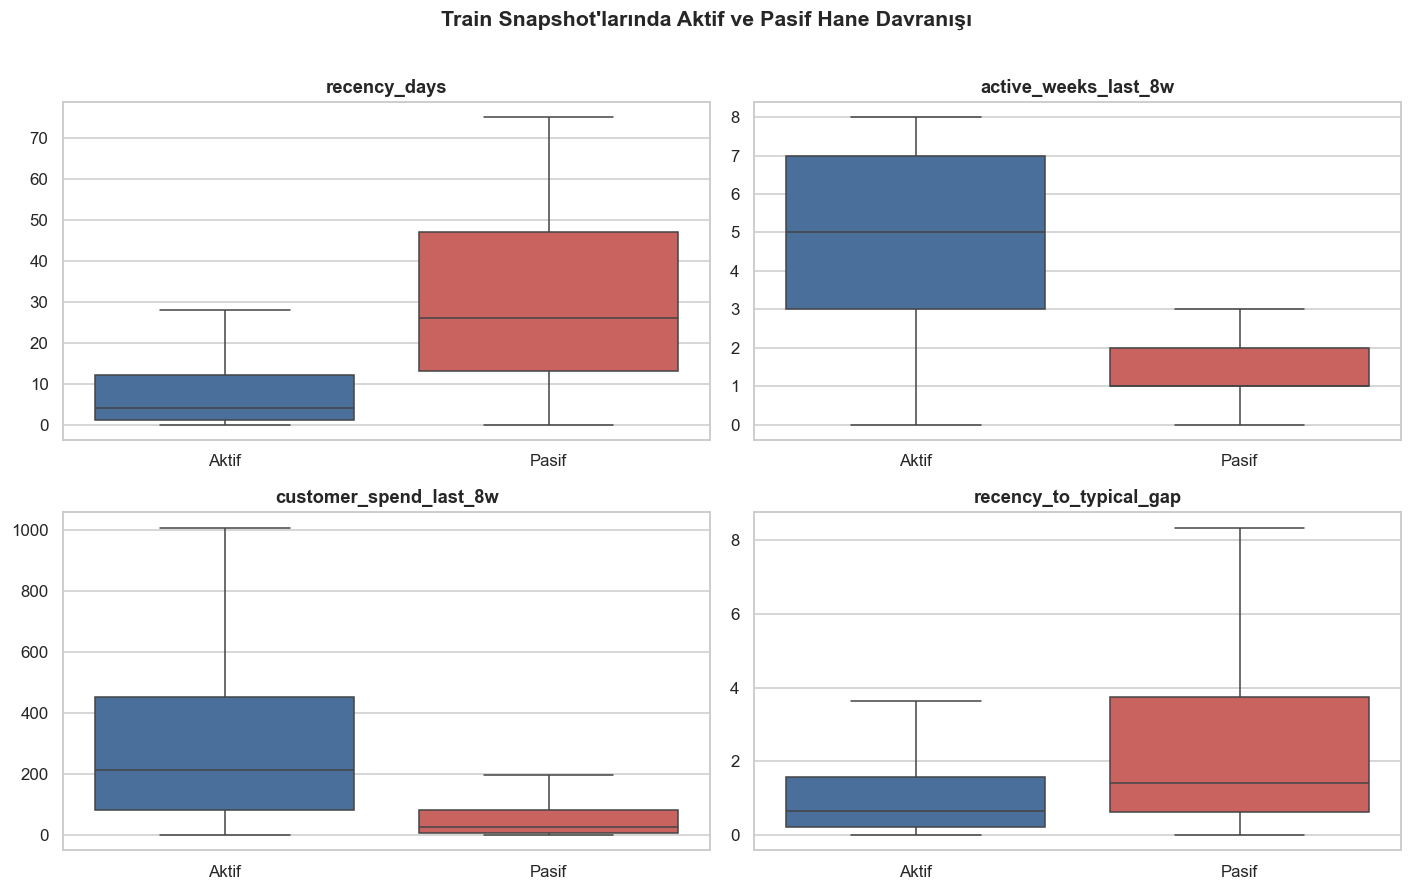

In [33]:
PROFILE_FEATURES = [
    "recency_days",
    "frequency_baskets",
    "customer_spend_total",
    "median_purchase_gap",
    "recency_to_typical_gap",
    "active_weeks_last_8w",
    "customer_spend_last_8w",
    "baskets_last_8w",
    "spend_change_8w",
    "basket_change_8w",
]

train_profile_data = household_snapshot_table.loc[train_rows]
target_profile = (
    train_profile_data.groupby("target_inactive")[PROFILE_FEATURES]
    .median()
    .T
    .rename(columns={0: "active_median", 1: "inactive_median"})
)
target_profile["inactive_minus_active"] = (
    target_profile["inactive_median"] - target_profile["active_median"]
)
display(target_profile)

plot_features = [
    "recency_days", "active_weeks_last_8w",
    "customer_spend_last_8w", "recency_to_typical_gap",
]
plot_data = train_profile_data.copy()
plot_data["class"] = plot_data["target_inactive"].map(
    {0: "Aktif", 1: "Pasif"}
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feature in zip(axes.flat, plot_features):
    clipped = plot_data[[feature, "class"]].copy()
    lower, upper = clipped[feature].quantile([0.01, 0.99])
    clipped[feature] = clipped[feature].clip(lower=lower, upper=upper)
    sns.boxplot(
        data=clipped,
        x="class",
        y=feature,
        hue="class",
        order=["Aktif", "Pasif"],
        palette={"Aktif": COLORS["blue"], "Pasif": COLORS["red"]},
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Train Snapshot'larında Aktif ve Pasif Hane Davranışı",
    y=1.01,
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 24. Feature sözlüğünün oluşturulması

Feature sözlüğü her sütunun kaynağını, iş anlamını, train eksiklik oranını ve hangi
deney setinde bulunduğunu kaydeder. Böylece modelleme, SHAP açıklaması ve Streamlit
uygulamasında aynı feature aynı anlamla kullanılır.

In [34]:
KNOWN_DESCRIPTIONS = {
    "recency_days": "Snapshot ile son geçerli alışveriş günü arasındaki gün sayısı",
    "frequency_baskets": "182 günlük gözlem penceresindeki geçerli sepet sayısı",
    "customer_spend_total": "Gözlem penceresindeki tahmini toplam müşteri ödemesi",
    "retailer_revenue_total": "Gözlem penceresindeki toplam perakendeci geliri",
    "active_days": "Alışveriş yapılan benzersiz gün sayısı",
    "active_weeks": "Alışveriş yapılan göreli hafta sayısı",
    "active_week_ratio": "Aktif haftaların 26 haftalık gözlem penceresine oranı",
    "discount_dependency": "Toplam indirimin tahmini indirimsiz alışveriş değerine oranı",
    "median_basket_value": "Sıfıra sınırlandırılmış müşteri sepet tutarının medyanı",
    "basket_value_cv": "Sepet tutarı standart sapmasının ortalama sepet tutarına oranı",
    "median_purchase_gap": "Alışveriş günleri arasındaki medyan gün sayısı",
    "recent_mean_purchase_gap_3": "Son üç alışveriş aralığının ortalaması",
    "gap_acceleration": "Son alışveriş aralığı ile tarihsel medyan aralık farkı",
    "gap_trend_last_5": "Son beş alışveriş aralığının doğrusal eğimi",
    "recency_to_typical_gap": "Mevcut sessizliğin tipik alışveriş aralığına oranı",
    "department_hhi": "Departman gelir paylarının kareleri toplamı; kategori yoğunlaşması",
    "department_entropy": "Departman gelir dağılımının normalize çeşitlilik ölçüsü",
    "department_retention_rate": "Önceki 8 hafta departmanlarının son 8 haftada korunma oranı",
    "department_jaccard": "Son ve önceki 8 hafta departman kümelerinin Jaccard benzerliği",
    "fuel_revenue_share": "Yakıt ilişkili ürünlerin ürün gelirindeki payı",
    "fuel_basket_rate": "Yakıt içeren sepetlerin geçerli sepetlerdeki payı",
    "has_fuel_purchase": "Gözlem penceresinde en az bir yakıt alışverişi göstergesi",
    "has_previous_department_history": "Önceki 8 haftada kategori geçmişi bulunma göstergesi",
    "completed_campaigns_received": "Snapshot öncesinde tamamlanan atanmış kampanya sayısı",
    "active_campaigns_at_snapshot": "Snapshot gününde devam eden atanmış kampanya sayısı",
    "coupon_redemption_events_obs": "Gözlem penceresindeki kupon kullanım kaydı sayısı",
    "redemption_campaign_share": "Kupon kullanılan tamamlanmış kampanyaların tamamlanmış kampanyalara oranı",
    "has_bc_coupon_opportunity": "Tamamlanmış Type B/C kampanyalarında bilinen kupon fırsatı göstergesi",
    "bc_coupon_redemption_rate": "Tamamlanmış Type B/C kupon fırsatlarında benzersiz kullanım oranı",
    "has_demographic": "Hanenin demografi kaydına sahip olma göstergesi",
    "demographic_unknown_count": "Demografi kaydı içindeki Unknown/None-Unknown alan sayısı",
    "has_internal_demographic_unknown": "Mevcut demografi kaydında en az bir belirsiz/eksik alan göstergesi",
}


def infer_feature_group(feature):
    if feature in DEMOGRAPHIC_COLUMNS or feature.startswith("demographic_") or feature in {
        "has_demographic", "has_internal_demographic_unknown"
    }:
        return "demographic"
    if any(token in feature for token in [
        "last_4w", "last_8w", "last_12w", "prev_8w", "change_",
        "slope_12w", "weekly_", "recent_spend_share",
    ]):
        return "temporal_trend"
    if any(token in feature for token in [
        "campaign", "redemption", "coupon_opportunities", "bc_coupon",
    ]):
        return "campaign_coupon"
    if any(token in feature for token in [
        "department", "commodity", "brand", "fuel", "gift_ticket", "misc",
        "repeat_product",
    ]):
        return "product_category"
    if any(token in feature for token in [
        "purchase_gap", "gap_", "recency_to_typical",
    ]):
        return "purchase_regularity"
    if any(token in feature for token in [
        "basket_value", "products_per_basket", "single_product", "basket_rate",
        "transaction_hour", "morning", "afternoon", "evening", "night",
        "dominant_store", "avg_basket_discount", "nonpositive_basket",
    ]):
        return "basket_store_time"
    return "rfm_activity_discount"


SOURCE_BY_GROUP = {
    "rfm_activity_discount": "transaction_data + valid basket events",
    "basket_store_time": "transaction_data aggregated to basket",
    "purchase_regularity": "valid basket purchase days",
    "temporal_trend": "transaction_data + basket + product time windows",
    "product_category": "transaction_data + product",
    "campaign_coupon": "campaign_table + campaign_desc + coupon + coupon_redempt",
    "demographic": "hh_demographic",
}


def infer_window(feature):
    for marker, label in {
        "last_4w": "last 4 weeks",
        "last_8w": "last 8 weeks",
        "last_12w": "last 12 weeks",
        "prev_8w": "previous 8 weeks",
        "26w": "182-day observation window",
    }.items():
        if marker in feature:
            return label
    if "panel_tenure" in feature or "last_redemption" in feature:
        return "all history up to snapshot"
    return "182-day observation window"


def describe_feature(feature):
    if feature in KNOWN_DESCRIPTIONS:
        return KNOWN_DESCRIPTIONS[feature]
    if feature.startswith("dept_revenue_share_"):
        department = feature.removeprefix("dept_revenue_share_").replace("_", " ").upper()
        return f"{department} departmanının hane ürün gelirindeki payı"
    if feature.startswith("completed_campaigns_received_"):
        campaign_type = feature.removeprefix("completed_campaigns_received_")
        return f"Snapshot öncesinde tamamlanan {campaign_type} kampanya sayısı"
    if feature.startswith("coupon_redemption_events_obs_"):
        campaign_type = feature.removeprefix("coupon_redemption_events_obs_")
        return f"Gözlem penceresindeki {campaign_type} kupon kullanım kaydı sayısı"
    if feature in DEMOGRAPHIC_COLUMNS:
        return (
            f"Anonim {feature} kategorisi; NO_DEMOGRAPHIC_RECORD ve belirsiz "
            "değerler ayrı korunur"
        )
    return "Snapshot gününe kadar gözlenen hane davranışından türetilen aday feature"


dictionary_records = []
for feature in ALL_CANDIDATE_FEATURES:
    group = infer_feature_group(feature)
    dictionary_records.append({
        "feature": feature,
        "group": group,
        "source": SOURCE_BY_GROUP[group],
        "window": infer_window(feature),
        "dtype": str(household_snapshot_table[feature].dtype),
        "description": describe_feature(feature),
        "missing_count_train": int(feature_quality.loc[feature, "missing_count_train"]),
        "missing_ratio_train": float(feature_quality.loc[feature, "missing_ratio_train"]),
        "constant_in_train": feature in CONSTANT_FEATURES_TRAIN,
        "in_behavior_core_linear": feature in FEATURE_SETS["behavior_core_linear"],
        "in_behavior_core": feature in FEATURE_SETS["behavior_core"],
        "in_behavior_plus_context": feature in FEATURE_SETS["behavior_plus_context"],
        "in_demographic_experiment": feature in FEATURE_SETS["demographic_experiment"],
    })

feature_dictionary = pd.DataFrame(dictionary_records)
feature_group_summary = (
    feature_dictionary.groupby("group")
    .agg(
        candidate_features=("feature", "size"),
        linear_core_features=("in_behavior_core_linear", "sum"),
        behavior_core_features=("in_behavior_core", "sum"),
        context_model_features=("in_behavior_plus_context", "sum"),
    )
    .sort_values("candidate_features", ascending=False)
)
display(feature_group_summary)

,candidate_features,linear_core_features,behavior_core_features,context_model_features
group,,,,
temporal_trend,68,15,15,15
rfm_activity_discount,32,9,10,18
campaign_coupon,22,0,0,15
product_category,21,0,0,14
basket_store_time,20,7,7,7
purchase_regularity,12,6,6,6
demographic,10,0,0,1


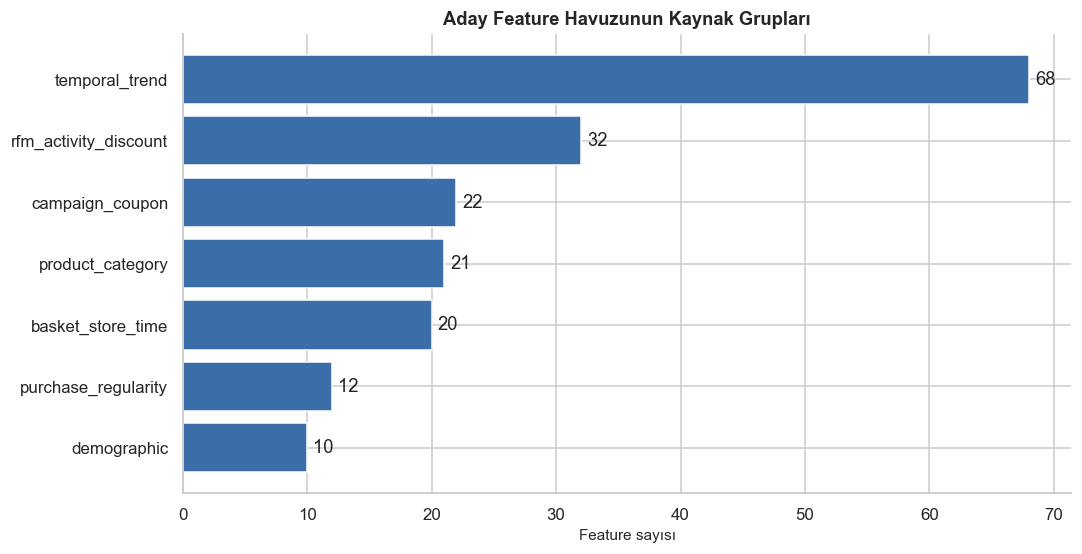

In [35]:
group_plot = feature_group_summary.sort_values("candidate_features")
fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.barh(
    group_plot.index,
    group_plot["candidate_features"],
    color=COLORS["blue"],
)
ax.bar_label(
    bars,
    labels=[f"{int(value)}" for value in group_plot["candidate_features"]],
    padding=4,
)
ax.set_title("Aday Feature Havuzunun Kaynak Grupları")
ax.set_xlabel("Feature sayısı")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 25. Modelleme dosyalarının kaydedilmesi

| Çıktı | İçerik |
|---|---|
| `household_snapshot_model_table.parquet` | Train-sabit sütunları çıkarılmış panel |
| `feature_sets.json` | Lineer core, tam behavior, context ve demografi deney listeleri |
| `feature_dictionary.csv` | Feature anlamı, kaynak, pencere ve eksiklik |
| `target_sensitivity.csv` | Hedef ufku × aktiflik kuralı karşılaştırması |
| `target_snapshot_summary.csv` | Snapshot bazında sınıf dağılımı |
| `target_split_summary.csv` | Train/validation/test bazında sınıf ve naif baseline özeti |
| `feature_quality_train.csv` | Yalnızca train dönemindeki kalite raporu |
| `high_correlation_pairs_train.csv` | Train yüksek korelasyon çiftleri |
| `leakage_checks.csv` | Sızıntı ve bütünlük kontrolleri |
| `target_design.json` | Nihai tasarım, panel bağımlılığı ve doğrulama protokolü |

Model tablosunda `household_key`, `snapshot_day` ve `dataset_split` korunur;
ancak bunlar model feature'ı değildir. 06 notebook'u feature listesini
`feature_sets.json` dosyasından okumalıdır.

In [36]:
model_output_table = household_snapshot_table.drop(
    columns=CONSTANT_FEATURES_TRAIN
).copy()

ordered_columns = (
    [
        "household_key", "snapshot_day", "observation_start_day",
        "prediction_start_day", "prediction_end_day", "dataset_split",
    ]
    + [
        column for column in model_output_table.columns
        if column not in METADATA_COLUMNS
    ]
    + ["target_inactive"]
)
model_output_table = model_output_table[ordered_columns]

model_output_path = PROCESSED_PATH / "household_snapshot_model_table.parquet"
feature_sets_path = PROCESSED_PATH / "feature_sets.json"
dictionary_output_path = INTERIM_PATH / "feature_dictionary.csv"
sensitivity_output_path = INTERIM_PATH / "target_sensitivity.csv"
snapshot_summary_path = INTERIM_PATH / "target_snapshot_summary.csv"
split_summary_path = INTERIM_PATH / "target_split_summary.csv"
quality_output_path = INTERIM_PATH / "feature_quality_train.csv"
correlation_output_path = INTERIM_PATH / "high_correlation_pairs_train.csv"
leakage_output_path = INTERIM_PATH / "leakage_checks.csv"
metadata_output_path = INTERIM_PATH / "target_design.json"

model_output_table.to_parquet(model_output_path, index=False)
feature_dictionary.to_csv(dictionary_output_path, index=False)
target_sensitivity.to_csv(sensitivity_output_path, index=False)
target_snapshot_summary.to_csv(snapshot_summary_path, index=False)
target_split_summary.to_csv(split_summary_path, index=False)
feature_quality.reset_index(names="feature").to_csv(quality_output_path, index=False)
high_correlation_pairs.to_csv(correlation_output_path, index=False)
leakage_checks.to_csv(leakage_output_path, index=False)

with feature_sets_path.open("w", encoding="utf-8") as file:
    json.dump(FEATURE_SETS, file, ensure_ascii=False, indent=2)

target_metadata = {
    "analysis_unit": "household_key x snapshot_day",
    "observation_window_days": OBSERVATION_WINDOW_DAYS,
    "prediction_window_days": PREDICTION_WINDOW_DAYS,
    "active_lookback_days": ACTIVE_LOOKBACK_DAYS,
    "minimum_history_days": MIN_HISTORY_DAYS,
    "minimum_baskets_in_observation": MIN_BASKETS_IN_OBSERVATION,
    "snapshot_days": SNAPSHOT_DAYS,
    "train_snapshot_days": TRAIN_SNAPSHOT_DAYS,
    "validation_snapshot_days": VALIDATION_SNAPSHOT_DAYS,
    "test_snapshot_days": TEST_SNAPSHOT_DAYS,
    "target_definition": "no valid purchase basket in prediction window",
    "monetary_definition": "customer_paid_value = sales_value + coupon_disc",
    "category_value_definition": "retailer_revenue on non-accounting product lines",
    "rows": int(len(model_output_table)),
    "unique_households": int(model_output_table["household_key"].nunique()),
    "inactive_rows": int(model_output_table["target_inactive"].sum()),
    "inactive_rate": float(model_output_table["target_inactive"].mean()),
    "all_candidate_feature_count": len(ALL_CANDIDATE_FEATURES),
    "modeling_candidate_feature_count": len(MODELING_CANDIDATE_FEATURES),
    "constant_features_removed": CONSTANT_FEATURES_TRAIN,
    "top_departments_selected_from_train": TOP_DEPARTMENTS,
    "categorical_features": CATEGORICAL_FEATURES,
    "linear_redundant_features_removed": LINEAR_REDUNDANT_FEATURES,
    "positive_rows_by_split": {
        row["dataset_split"]: int(row["inactive_rows"])
        for _, row in target_split_summary.iterrows()
    },
    "panel_dependence": {
        "train_rows": int(train_rows.sum()),
        "train_unique_households": int(train_household_snapshot_counts.size),
        "train_households_in_multiple_snapshots": int(
            train_household_snapshot_counts.gt(1).sum()
        ),
        "same_household_may_appear_across_splits": True,
        "intended_scoring_population": "recurring households at later snapshots",
    },
    "validation_protocol": {
        "primary_split": "chronological snapshot holdout",
        "random_row_kfold_allowed": False,
        "optional_inner_tuning": "forward chaining by snapshot day",
        "group_kfold_role": "secondary cold-start household robustness only",
        "threshold_selection_split": "validation",
        "test_usage": "single final evaluation after all choices are frozen",
        "bootstrap_test_metrics": True,
        "bootstrap_unit": "household row within the single test snapshot",
        "recommended_bootstrap_repetitions_minimum": 1000,
        "confidence_level": 0.95,
    },
}
with metadata_output_path.open("w", encoding="utf-8") as file:
    json.dump(target_metadata, file, ensure_ascii=False, indent=2)

print(f"Model paneli          : {model_output_path} | {model_output_table.shape}")
print(f"Feature setleri       : {feature_sets_path}")
print(f"Feature sözlüğü       : {dictionary_output_path} | {feature_dictionary.shape}")
print(f"Hedef duyarlılığı     : {sensitivity_output_path}")
print(f"Snapshot özeti        : {snapshot_summary_path}")
print(f"Veri bölümü özeti     : {split_summary_path}")
print(f"Feature kalitesi      : {quality_output_path}")
print(f"Korelasyon raporu     : {correlation_output_path}")
print(f"Sızıntı kontrolleri   : {leakage_output_path}")
print(f"Hedef metadata        : {metadata_output_path}")

Model paneli          : ..\data\processed\household_snapshot_model_table.parquet | (11356, 192)
Feature setleri       : ..\data\processed\feature_sets.json
Feature sözlüğü       : ..\data\interim\feature_dictionary.csv | (185, 13)
Hedef duyarlılığı     : ..\data\interim\target_sensitivity.csv
Snapshot özeti        : ..\data\interim\target_snapshot_summary.csv
Veri bölümü özeti     : ..\data\interim\target_split_summary.csv
Feature kalitesi      : ..\data\interim\feature_quality_train.csv
Korelasyon raporu     : ..\data\interim\high_correlation_pairs_train.csv
Sızıntı kontrolleri   : ..\data\interim\leakage_checks.csv
Hedef metadata        : ..\data\interim\target_design.json


## 26. Sonuç ve 06 modellemeye geçiş kontrol listesi

Bu notebook tamamlandığında:

- [ ] Kaynak tablolar `data/interim` altından okunmuş olmalı.
- [ ] Ürün metin kalite tablosu incelenmeli; model kategorilerinde gizli boşluk
  veya `NaN` kalmamalı.
- [ ] Bütün ilişkisel kontroller `True` olmalı.
- [ ] Hedef duyarlılık tablosu sınıf oranı ve örneklem büyüklüğüyle incelenmiş olmalı.
- [ ] Her snapshot'ta hem gözlem hem hedef penceresi eksiksiz bulunmalı.
- [ ] Target ve feature recency hesapları için uyumsuzluk sayısı `0` olmalı.
- [ ] Bütün leakage kontrolleri `True` olmalı.
- [ ] Train, validation ve test snapshot'ları kronolojik olarak ayrılmalı.
- [ ] `household_key`, `snapshot_day` ve `dataset_split` model feature'ı yapılmamalı.
- [ ] Demografi ana davranış modeline zorunlu olarak eklenmemeli.
- [ ] Notebook `Restart Kernel and Run All` ile baştan sona hatasız çalıştırılmalı.

### 06 notebook'unda önerilen deney sırası

1. Kronolojik split'i aynen yükle; satır bazlı random split/CV kullanma.
2. `DummyClassifier` ile naif referansı kur.
3. `behavior_core_linear` + standardizasyon + class-weight ve L2 düzenlileştirmeli
   Logistic Regression çalıştır.
4. `behavior_core` + Random Forest / boosting modeli çalıştır.
5. `behavior_plus_context` ve `demographic_experiment` ablasyonlarını karşılaştır.
6. Hyperparameter ve threshold kararlarını validation snapshot'ında ver.
7. Test snapshot'ını yalnızca bütün kararlar dondurulduktan sonra bir kez değerlendir.
8. PR-AUC, recall, precision, F1/F2, Brier/calibration ve `recall@top-k` raporla.
9. Test PR-AUC, recall ve `recall@top-k` için en az 1.000 tekrarlı %95 bootstrap
   güven aralığı ekle; her tekrarda top-k sıralamasını yeniden hesapla.
10. SHAP veya lineer katsayılarla hane düzeyinde açıklama üret.

Train içinde ek CV gerekirse snapshot bazlı ileri-zincirleme tercih edilmelidir.
`GroupKFold(household_key)` zaman sırasını korumadığı için ana tuning yöntemi değil,
yalnızca hiç görülmemiş hanelere genellemeyi sorgulayan ikincil bir deneydir.

Model seçimi yalnızca en yüksek skora göre değil; pasif müşteriyi yakalama oranı,
yanlış alarm maliyeti, kalibrasyon, güven aralığı ve açıklanabilirlik birlikte
değerlendirilerek yapılmalıdır.